In [1]:
import pandas as pd
import numpy as np
import pickle
import re
import ast
import math
import warnings
from collections import Counter
from typing import List, Dict, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

warnings.filterwarnings('ignore')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM   : {total_mem:.1f} GB")

Device : cuda
GPU    : NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM   : 6.4 GB


## Data Loading

In [2]:
with open('data/glycan_embedding/df_glycan.pkl', 'rb') as f:
    df_glycan = pickle.load(f)

with open('data/glycan_embedding/glycan_binding.pkl', 'rb') as f:
    glycan_binding = pickle.load(f)

with open('data/glycan_embedding/N_glycans_df.pkl', 'rb') as f:
    N_glycans_df = pickle.load(f)

glycan_list = pd.read_csv('data/glycan_embedding/glycan_list.csv')
# Parse list-valued columns stored as strings in the CSV
glycan_list['tissue_sample']  = glycan_list['tissue_sample'].apply(ast.literal_eval)
glycan_list['tissue_species'] = glycan_list['tissue_species'].apply(ast.literal_eval)

print(f"{'Dataset':<20} {'Shape':<18} Notes")
print('-' * 70)
print(f"{'glycan_list':<20} {str(glycan_list.shape):<18} target glycans for inference")
print(f"{'df_glycan':<20} {str(df_glycan.shape):<18} main training corpus")
print(f"{'glycan_binding':<20} {str(glycan_binding.shape):<18} protein × glycan binding matrix")
print(f"{'N_glycans_df':<20} {str(N_glycans_df.shape):<18} N-glycan reference set")

Dataset              Shape              Notes
----------------------------------------------------------------------
glycan_list          (5, 4)             target glycans for inference
df_glycan            (50461, 23)        main training corpus
glycan_binding       (2122, 2880)       protein × glycan binding matrix
N_glycans_df         (15712, 22)        N-glycan reference set


## 2. Data Exploration
### 2.1 — `glycan_list` (inference targets)

In [3]:
print('dataset: glycan_list')
print(f'Shape   : {glycan_list.shape}')
print(f'Columns : {glycan_list.columns.tolist()}')
print()
display(glycan_list)

dataset: glycan_list
Shape   : (5, 4)
Columns : ['glycan', 'Composition', 'tissue_species', 'tissue_sample']



,glycan,Composition,tissue_species,tissue_sample
0,Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man...,"{'dHex': 2, 'HexNAc': 4, 'Hex': 3}",[Homo_sapiens],[blood]
1,Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4, 'dHex': 1}",[Homo_sapiens],[blood]
2,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal...,"{'Neu5Ac': 1, 'Hex': 5, 'HexNAc': 4}",[Homo_sapiens],[blood]
3,Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Glc...,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4}",[Homo_sapiens],[blood]
4,Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Ma...,"{'dHex': 1, 'HexNAc': 5, 'Hex': 5}",[Homo_sapiens],[blood]


### 2.2 — `df_glycan` (training corpus)

In [4]:
print('dataset: df_glycan')
print(f'Shape          : {df_glycan.shape}')
print(f'Unique glycans : {df_glycan["glycan"].nunique()}')
print(f'Columns        : {df_glycan.columns.tolist()}')

df_glycan.head()

dataset: df_glycan
Shape          : (50461, 23)
Unique glycans : 50461
Columns        : ['glycan', 'Species', 'Genus', 'Family', 'Order', 'Class', 'Phylum', 'Kingdom', 'Domain', 'ref', 'glytoucan_id', 'glycan_type', 'disease_association', 'disease_id', 'disease_sample', 'disease_direction', 'disease_ref', 'disease_species', 'tissue_sample', 'tissue_id', 'tissue_ref', 'tissue_species', 'Composition']


,glycan,Species,Genus,Family,Order,Class,Phylum,Kingdom,Domain,ref,...,disease_id,disease_sample,disease_direction,disease_ref,disease_species,tissue_sample,tissue_id,tissue_ref,tissue_species,Composition
0,Gal(b1-4)Glc-ol,"[Acinonyx_jubatus, Addax_nasomaculatus, Aepyce...","[Acinonyx, Addax, Aepyceros, Ailuropoda, Alcel...","[Felidae, Bovidae, Bovidae, Ursidae, Bovidae, ...","[Carnivora, Artiodactyla, Artiodactyla, Carniv...","[Mammalia, Mammalia, Mammalia, Mammalia, Mamma...","[Chordata, Chordata, Chordata, Chordata, Chord...","[Animalia, Animalia, Animalia, Animalia, Anima...","[Eukarya, Eukarya, Eukarya, Eukarya, Eukarya, ...","[https://pubmed.ncbi.nlm.nih.gov/31828568/, ht...",...,[],[],[],[],[],"[milk, milk, milk, milk, milk, milk, milk, mil...","[UBERON:0001913, UBERON:0001913, UBERON:000191...","[https://pubmed.ncbi.nlm.nih.gov/31828568/, ht...","[Acinonyx_jubatus, Addax_nasomaculatus, Aepyce...",{'Hex': 2}
1,Neu5Ac(a2-3)Gal(b1-4)Glc1Cer,"[Alces_alces, Balaenoptera_acutorostrata, Bos_...","[Alces, Balaenoptera, Bos, Bubalus, Campylobac...","[Cervidae, Balaenopteridae, Bovidae, Bovidae, ...","[Artiodactyla, Artiodactyla, Artiodactyla, Art...","[Mammalia, Mammalia, Mammalia, Mammalia, Epsil...","[Chordata, Chordata, Chordata, Chordata, Prote...","[Animalia, Animalia, Animalia, Animalia, Bacte...","[Eukarya, Eukarya, Eukarya, Eukarya, Bacteria,...","[https://pubmed.ncbi.nlm.nih.gov/26104834/, ht...",...,"[DOID:83, DOID:3068, DOID:5409, DOID:1909]","[lens, tumor, tumor, skin]","[up, up, up, up]","[https://pubmed.ncbi.nlm.nih.gov/7905480/, htt...","[Homo_sapiens, , Homo_sapiens, Cricetulus_gris...","[A549_cell_line, AML_193_cell_line, CHOK1_cell...","[cellosaurus:CVCL_0023, cellosaurus:CVCL_1071,...","[https://pubmed.ncbi.nlm.nih.gov/23345451/, ht...","[Homo_sapiens, Homo_sapiens, Homo_sapiens, Hom...","{'Hex': 2, 'Neu5Ac': 1}"
2,Man(a1-2)Man(a1-3)[Man(a1-3)[Man(a1-6)]Man(a1-...,"[Adeno-associated_dependoparvovirusA, Angiostr...","[Dependoparvovirus, Angiostrongylus, Apis, Ara...","[Parvoviridae, Angiostrongylidae, Apidae, Bras...","[Piccovirales, Rhabditida, Hymenoptera, Brassi...","[Quintoviricetes, Chromadorea, Insecta, Dicoty...","[Cossaviricota, Nematoda, Arthropoda, Angiospe...","[Shotokuvirae, Animalia, Animalia, Plantae, An...","[Virus, Eukarya, Eukarya, Eukarya, Eukarya, Eu...","[https://pubmed.ncbi.nlm.nih.gov/37774344/, ht...",...,"[DOID:9965, SYMP:0000633, DOID:3908, DOID:3969...","[serum, plasma, serum, serum, serum, urine]","[up, down, down, up, up, up]","[https://pubmed.ncbi.nlm.nih.gov/32123198/, ht...","[Mus_musculus, Homo_sapiens, Homo_sapiens, Hom...","[2A3_cell_line, B_cell, C10_cell_line, CHOK1_c...","[cellosaurus:CVCL_0D71, CL:0000236, cellosauru...","[https://pubmed.ncbi.nlm.nih.gov/36289103/, ht...","[Homo_sapiens, Homo_sapiens, Homo_sapiens, Cri...","{'Hex': 6, 'HexNAc': 2}"
3,Man(a1-2)Man(a1-2)Man(a1-3)[Man(a1-2)Man(a1-3)...,"[Acanthocheilonema_viteae, Apis_mellifera, Ara...","[Acanthocheilonema, Apis, Arabidopsis, Bombyx,...","[Onchocercidae, Apidae, Brassicaceae, Bombycid...","[Rhabditida, Hymenoptera, Brassicales, Lepidop...","[Chromadorea, Insecta, Dicotyledons, Insecta, ...","[Nematoda, Arthropoda, Angiosperms, Arthropoda...","[Animalia, Animalia, Plantae, Animalia, Animal...","[Eukarya, Eukarya, Eukarya, Eukarya, Eukarya, ...","[https://pubmed.ncbi.nlm.nih.gov/9108548/, , h...",...,"[DOID:0060224, SYMP:0000633, DOID:3908, DOID:3...","[serum, plasma, serum, serum, urine]","[up, down, up, up, up]","[https://pubmed.ncbi.nlm.nih.gov/37189353/, ht...","[Homo_sapiens, Homo_sapiens, Homo_sapiens, Hom...","[2A3_cell_line, BMMC_cell_line, B_cell, C10_ce...","[cellosaurus:CVCL_0D71, CL:0010004, CL:0000236...","[https://pubmed.ncbi.nlm.nih.gov/36289103/, ht...","[Homo_sapiens, Homo_sapiens, Homo_sapiens, Hom...","{'Hex': 9, 'HexNAc': 2}"
4,Man(a1-3)[Man(a1-6)]Man(a1-6)[Man(a1-3)]Man(b1...,"[Abrus_precatorius, Adeno-associated_dependopa...","[Abrus, Dependoparvovirus, Anacardium, Angiost...","[Fabaceae, 

In [5]:
print('--- Non-null counts ---')
print(df_glycan.notna().sum().to_string())
print()

print('--- glycan_type distribution ---')
print(df_glycan['glycan_type'].value_counts().to_string())
print()

print('--- Kingdom distribution (flattened, top 8) ---')
kingdom_flat = [k for klist in df_glycan['Kingdom']
                for k in (klist if isinstance(klist, list) else [klist]) if k]
print(pd.Series(kingdom_flat).value_counts().head(8).to_string())
print()

print('--- Sample: disease_association (first 4 glycans) ---')
for _, row in df_glycan.head(4).iterrows():
    diseases = row['disease_association']
    print(f'  {row["glycan"][:65]}...')
    print(f'    -> {diseases[:4]}')
print()

print('--- Sample: tissue_sample (first 4 glycans, unique values) ---')
for _, row in df_glycan.head(4).iterrows():
    tissues = list(set(row['tissue_sample'])) if isinstance(row['tissue_sample'], list) else []
    print(f'  {row["glycan"][:65]}...')
    print(f'    -> {tissues[:6]}')

--- Non-null counts ---
glycan                 50461
Species                50461
Genus                  50461
Family                 50461
Order                  50461
Class                  50461
Phylum                 50461
Kingdom                50461
Domain                 50461
ref                    50461
glytoucan_id           33450
glycan_type            27171
disease_association    50461
disease_id             50461
disease_sample         50461
disease_direction      50461
disease_ref            50461
disease_species        50461
tissue_sample          50461
tissue_id              50461
tissue_ref             50461
tissue_species         50461
Composition            50461

--- glycan_type distribution ---
glycan_type
N         15712
O          4234
free       3384
repeat     2628
lipid      1213

--- Kingdom distribution (flattened, top 8) ---
Animalia         21007
Bacteria          9050
Plantae           4527
Fungi             3426
Excavata           572
Riboviria          

### 2.3 — `glycan_binding` (protein–glycan binding matrix)

In [6]:
glycan_binding.head()

,3-Anhydro-Gal(a1-3)Gal(b1-4)3-Anhydro-Gal(a1-3)Gal4S,3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S,3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S,3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S,3-Anhydro-Gal(a1-3)Gal4S(b1-4)3-Anhydro-Gal2S(a1-3)Gal4S(b1-4)3-Anhydro-Gal(a1-3)Gal4S,3dGal,3dGal(b1-3)[Fuc(a1-4)]Glc,3dGal(b1-4)Glc,4d8dNeu5Ac(a2-3)Gal(b1-4)Glc,4dNeu5Ac(a2-3)Gal(b1-4)Glc,...,Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl,Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl,Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl,Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl,Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl,Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl,Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl,Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl(b1-4)Xyl,target,protein
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AADSIPSISPTGIITPTPTQSGMVSNCNKFYDVHSNDGCSAIASSQ...,TAL6-4LysM
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AAFFSLVVLLALLPFGIHASALPSTELTPRVNPNLPGPNDVFVGFR...,rCnSL-proA
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AANEADYQAKLTAYQTELARVQKANADAKAAYEAAVAANNAANAAL...,AntigenI/IIA3VP1
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,AASKLGVPQPAQRDQVNCQLYAVQPNDNCIDISSKNNITYAQLLSW...,TAL6-6LysM
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACNNEWEDEQYEQYISFKSPIPAGGEGVTDIYVRYKEDGKVTYRLP...,SP15308A-bot-339-19-339


dataset: glycan_binding
Shape total    : (2122, 2880)  (rows = proteins, cols = glycans + 2 metadata)
Protein rows   : 2122
Glycan columns : 2878
Metadata cols  : ["target", "protein"]

--- Sparsity ---
Total entries  : 6,107,116
Non-null       : 799,408  (13.1% fill rate)

--- Glycans covered per protein ---
  min=0  max=1927  mean=376.7  median=416
--- Proteins covering each glycan ---
  min=1  max=1945  mean=277.8  median=22

--- Binding value distribution (z-scores) ---
  min=-11.355  max=23.892  mean=-0.039  std=0.847

--- Sample protein names (first 8) ---
['TAL6-4LysM', 'rCnSL-proA', 'AntigenI/IIA3VP1', 'TAL6-6LysM', 'SP15308A-bot-339-19-339', 'VLRB.aGPA.23-GCN4-biotin', 'Protein L(A-C2)', 'A/H16-2']

--- Top 3 most-covered glycans ---
  [1945 proteins]  Gal(b1-4)GlcNAc
  [1941 proteins]  Gal(b1-4)Glc
  [1938 proteins]  Neu5Ac(a2-3)Gal(b1-4)[Fuc(a1-3)]GlcNAc


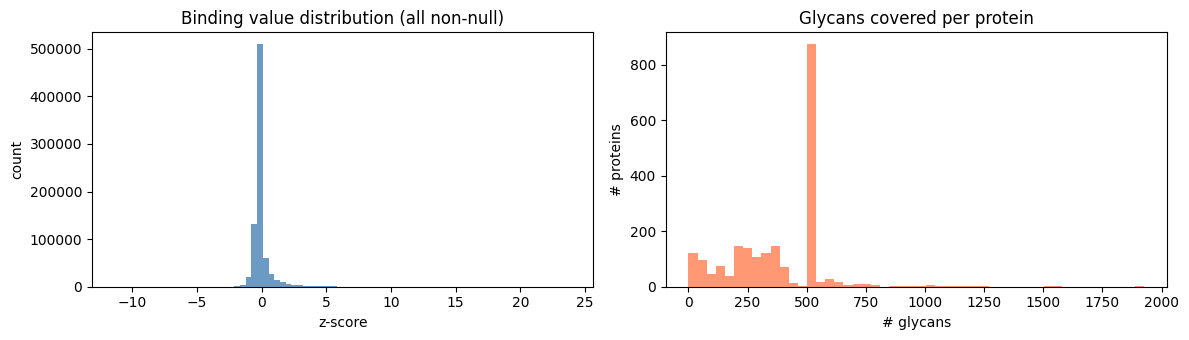

In [7]:
glycan_cols = [c for c in glycan_binding.columns if c not in ['target', 'protein']]
binding_vals = glycan_binding[glycan_cols]

print('dataset: glycan_binding')
print(f'Shape total    : {glycan_binding.shape}  (rows = proteins, cols = glycans + 2 metadata)')
print(f'Protein rows   : {len(glycan_binding)}')
print(f'Glycan columns : {len(glycan_cols)}')
print(f'Metadata cols  : ["target", "protein"]')
print()

total      = binding_vals.size
non_null   = int(binding_vals.notna().sum().sum())
print(f'--- Sparsity ---')
print(f'Total entries  : {total:,}')
print(f'Non-null       : {non_null:,}  ({non_null/total*100:.1f}% fill rate)')
print()

nn_per_protein = binding_vals.notna().sum(axis=1)
nn_per_glycan  = binding_vals.notna().sum(axis=0)
print(f'--- Glycans covered per protein ---')
print(f'  min={nn_per_protein.min()}  max={nn_per_protein.max()}  '
      f'mean={nn_per_protein.mean():.1f}  median={nn_per_protein.median():.0f}')
print(f'--- Proteins covering each glycan ---')
print(f'  min={nn_per_glycan.min()}  max={nn_per_glycan.max()}  '
      f'mean={nn_per_glycan.mean():.1f}  median={nn_per_glycan.median():.0f}')
print()

all_vals = binding_vals.values.flatten()
all_vals = all_vals[~np.isnan(all_vals.astype(float))]
print(f'--- Binding value distribution (z-scores) ---')
print(f'  min={all_vals.min():.3f}  max={all_vals.max():.3f}  '
      f'mean={all_vals.mean():.3f}  std={all_vals.std():.3f}')
print()

print('--- Sample protein names (first 8) ---')
print(glycan_binding['protein'].head(8).tolist())
print()

print('--- Top 3 most-covered glycans ---')
for glycan, count in nn_per_glycan.nlargest(3).items():
    print(f'  [{count} proteins]  {glycan[:80]}')

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(all_vals, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Binding value distribution (all non-null)')
axes[0].set_xlabel('z-score'); axes[0].set_ylabel('count')
axes[1].hist(nn_per_protein.values, bins=50, color='coral', edgecolor='none', alpha=0.8)
axes[1].set_title('Glycans covered per protein')
axes[1].set_xlabel('# glycans'); axes[1].set_ylabel('# proteins')
plt.tight_layout(); plt.show()

### 2.4 — `N_glycans_df` (N-glycan reference set)

In [8]:
N_glycans_df.head()

,Species,Genus,Family,Order,Class,Phylum,Kingdom,Domain,ref,glytoucan_id,...,disease_id,disease_sample,disease_direction,disease_ref,disease_species,tissue_sample,tissue_id,tissue_ref,tissue_species,Composition
glycan,,,,,,,,,,,,,,,,,,,,,
Man(a1-2)Man(a1-3)[Man(a1-3)[Man(a1-6)]Man(a1-6)]Man(b1-4)GlcNAc(b1-4)GlcNAc,"[Adeno-associated_dependoparvovirusA, Angiostr...","[Dependoparvovirus, Angiostrongylus, Apis, Ara...","[Parvoviridae, Angiostrongylidae, Apidae, Bras...","[Piccovirales, Rhabditida, Hymenoptera, Brassi...","[Quintoviricetes, Chromadorea, Insecta, Dicoty...","[Cossaviricota, Nematoda, Arthropoda, Angiospe...","[Shotokuvirae, Animalia, Animalia, Plantae, An...","[Virus, Eukarya, Eukarya, Eukarya, Eukarya, Eu...","[https://pubmed.ncbi.nlm.nih.gov/37774344/, ht...",G96417BZ,...,"[DOID:9965, SYMP:0000633, DOID:3908, DOID:3969...","[serum, plasma, serum, serum, serum, urine]","[up, down, down, up, up, up]","[https://pubmed.ncbi.nlm.nih.gov/32123198/, ht...","[Mus_musculus, Homo_sapiens, Homo_sapiens, Hom...","[2A3_cell_line, B_cell, C10_cell_line, CHOK1_c...","[cellosaurus:CVCL_0D71, CL:0000236, cellosauru...","[https://pubmed.ncbi.nlm.nih.gov/36289103/, ht...","[Homo_sapiens, Homo_sapiens, Homo_sapiens, Cri...","{'Hex': 6, 'HexNAc': 2}"
Man(a1-2)Man(a1-2)Man(a1-3)[Man(a1-2)Man(a1-3)[Man(a1-2)Man(a1-6)]Man(a1-6)]Man(b1-4)GlcNAc(b1-4)GlcNAc,"[Acanthocheilonema_viteae, Apis_mellifera, Ara...","[Acanthocheilonema, Apis, Arabidopsis, Bombyx,...","[Onchocercidae, Apidae, Brassicaceae, Bombycid...","[Rhabditida, Hymenoptera, Brassicales, Lepidop...","[Chromadorea, Insecta, Dicotyledons, Insecta, ...","[Nematoda, Arthropoda, Angiosperms, Arthropoda...","[Animalia, Animalia, Plantae, Animalia, Animal...","[Eukarya, Eukarya, Eukarya, Eukarya, Eukarya, ...","[https://pubmed.ncbi.nlm.nih.gov/9108548/, , h...",G77301ZL,...,"[DOID:0060224, SYMP:0000633, DOID:3908, DOID:3...","[serum, plasma, serum, serum, urine]","[up, down, up, up, up]","[https://pubmed.ncbi.nlm.nih.gov/37189353/, ht...","[Homo_sapiens, Homo_sapiens, Homo_sapiens, Hom...","[2A3_cell_line, BMMC_cell_line, B_cell, C10_ce...","[cellosaurus:CVCL_0D71, CL:0010004, CL:0000236...","[https://pubmed.ncbi.nlm.nih.gov/36289103/, ht...","[Homo_sapiens, Homo_sapiens, Homo_sapiens, Hom...","{'Hex': 9, 'HexNAc': 2}"
Man(a1-3)[Man(a1-6)]Man(a1-6)[Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc,"[Abrus_precatorius, Adeno-associated_dependopa...","[Abrus, Dependoparvovirus, Anacardium, Angiost...","[Fabaceae, Parvoviridae, Anacardiaceae, Angios...","[Fabales, Piccovirales, Sapindales, Rhabditida...","[Dicotyledons, Quintoviricetes, Dicotyledons, ...","[Angiosperms, Cossaviricota, Angiosperms, Nema...","[Plantae, Shotokuvirae, Plantae, Animalia, Pla...","[Eukarya, Virus, Eukarya, Eukarya, Eukarya, Eu...","[, https://pubmed.ncbi.nlm.nih.gov/37774344/, ...",G77007QN,...,"[DOID:0060224, SYMP:0000633, DOID:11503, DOID:...","[serum, plasma, urine, serum, serum, serum]","[up, down, down, up, up, up]","[https://pubmed.ncbi.nlm.nih.gov/37189353/, ht...","[Homo_sapiens, Homo_sapiens, Homo_sapiens, Mac...","[BMMC_cell_line, B_cell, C10_cell_line, CHOK1_...","[CL:0010004, CL:0000236, cellosaurus:CVCL_5245...",[http://www.functionalglycomics.org/glycomics/...,"[Homo_sapiens, Homo_sapiens, Homo_sapiens, Cri...","{'Hex': 5, 'HexNAc': 2}"
Man(a1-3)[Man(a1-6)]Man(b1-4)GlcNAc(b1-4)GlcNAc,"[Acanthocheilonema_viteae, Adeno-associated_de...","[Acanthocheilonema, Dependoparvovirus, Aedes, ...","[Onchocercidae, Parvoviridae, Culicidae, Agele...","[Rhabditida, Piccovirales, Diptera, Araneae, R...","[Chromadorea, Quintoviricetes, Insecta, Arachn...","[Nematoda, Cossaviricota, Arthropoda, Arthropo...","[Animalia, Shotokuvirae, Animalia, Animalia, A...","[Eukarya, Virus, Eukarya, Eukarya, Eukarya, Eu...","[https://pubmed.ncbi.nlm.nih.gov/9108548/, htt...",G42730YE,...,"[, , DOID:1485, DOID:0050671, DOID:10283, DOID...","[striatum, breast, sputum, cell_line, prostate...","[up, up, up, up, up, down]",[https://jneuroinflam

In [9]:
print('=== N_glycans_df ===')
print(f'Shape          : {N_glycans_df.shape}')
print(f'Index (glycan) : {N_glycans_df.index.name}  — dtype: {N_glycans_df.index.dtype}')
print(f'Columns        : {N_glycans_df.columns.tolist()}')
print()

print('--- Non-null counts ---')
print(N_glycans_df.notna().sum().to_string())
print()

print('--- glycan_type (should all be N) ---')
print(N_glycans_df['glycan_type'].value_counts().to_string())
print()

n_in_dfglycan = sum(1 for s in N_glycans_df.index if s in set(df_glycan['glycan'].tolist()))
print(f'Overlap with df_glycan : {n_in_dfglycan} / {len(N_glycans_df)}')
print()

print('--- Sample N-glycan sequences ---')
for seq in N_glycans_df.index[:5]:
    print(f'  {seq}')

=== N_glycans_df ===
Shape          : (15712, 22)
Index (glycan) : glycan  — dtype: str
Columns        : ['Species', 'Genus', 'Family', 'Order', 'Class', 'Phylum', 'Kingdom', 'Domain', 'ref', 'glytoucan_id', 'glycan_type', 'disease_association', 'disease_id', 'disease_sample', 'disease_direction', 'disease_ref', 'disease_species', 'tissue_sample', 'tissue_id', 'tissue_ref', 'tissue_species', 'Composition']

--- Non-null counts ---
Species                15712
Genus                  15712
Family                 15712
Order                  15712
Class                  15712
Phylum                 15712
Kingdom                15712
Domain                 15712
ref                    15712
glytoucan_id           10947
glycan_type            15712
disease_association    15712
disease_id             15712
disease_sample         15712
disease_direction      15712
disease_ref            15712
disease_species        15712
tissue_sample          15712
tissue_id              15712
tissue_ref    

## Embedding method explanation

After seeing what the data looks like, and reading about how Glycan sequences are written in the glycowork documentation, the best method that comes to my head is to apply embedding techniques used for Natural Language Processing (NLP) to the glycan sequences, and try to add metadata corresponding to the remaining columns in ```glycan_list```, so we can use them as features. Why did I choose to use NLP techniques? It's because the graph or tree-structure of the glycan has been linearized in text form by using brackets '[' ']' to indicate a branch and parantheses '(' ')' to indicate linkage type. Therefore the graph structure information is retained in text form. In the glycowork library, they use graph neural networks, however deep learning architectures in NLP are much more advanced and covered in the literature (they get more interest in industry/academia), especially by the use of transformer architecture. With classic nlp embedding techniques like GloVe or Word2Vec we do not get context-aware embeddings of tokens, while with transformer-based architecture each molecule, linkage, branch embedding depends on the context (i.e the sequence + metadata) by attending to each other with the attention mechanism. Plus, transformers are much more expressive: with the attention mechanism + positional encoding, the model can learn that what's between parantheses always comes between two molecules so serves as a link, and also can learn that brackets serves as an indication of a branch start.

Since we don't need a generative model, we're going to implement an encoder-only model, and the most famous one is BERT, which uses a Masked Language Modeling objective. We will call our model GlycanBERT, and we'll call our object Masked Molecule Modeling (although we also mask linkages, brackets, and metadata, but the training takes a lot of time and I've thought about this name before thinking about masking the other types of tokens).

## Tokenization & Vocabulary

Like all transformer-based architectures, we must define our atomic entities, a.k.a tokens. Unlike natural language, with glycan sequences, the tokens are quite explicit. In natural language, the definition of a word is very ambiguous, for example do you take "New York" as a unit or do you break it to "New" and "York"? For subwords like prefixes, suffixes and radicals, how would define these for each know words? That's why in natural language, we learn the tokens by leveraging statistical properties of the corpus (like BPE tokenization where we start with bytes/characters as tokens and we merge the most frequent consecutive token pair to create a new token in each iteration). In our case, the most expressive and semantic units are the molecules, branch indication, and linkages, so we're going to use those as tokens, and for any unseen token we're going to replace it with a special token ```<UNK>```
Example:
```
Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc
->['Neu5Ac', '(a2-6)', 'Gal', '(b1-4)', 'GlcNAc', '(b1-2)', 'Man', '(a1-6)', '[', 'Gal', '(b1-4)', ...]
```
Metadata tokens for tissue and species are prepended to the sequence as special tokens.

In [10]:
# Tokenizer: residue tokens + linkage-group tokens + branch brackets
#
# Strategy (in regex alternation order):
#   1. Branch brackets   [  ]
#   2. Linkage group     (a1-2), (b1-4), (a2-?), (1-4)  parentheses consumed first
#      so digits inside parentheses NEVER leak out as standalone tokens
#   3. Molecule name      Man, GlcNAc, Neu5Ac, 0dHex, 1dAlt-ol
#      [0-9]*[A-Za-z][...] requires at least one letter, preventing lone digits
#   4. Standalone linkage  a1-2  (rare fallback, no surrounding parentheses)

def preprocess_glycan(seq: str) -> str:
    """Normalise non-ASCII Greek letters and arrow notation."""
    return seq.replace('α', 'a').replace('β', 'b').replace('→', '-')

TOKEN_RE = re.compile(
    r'\[|\]'                                # 1. branch brackets
    r'|\([a-zA-Z0-9?,/\-]+\)'             # 2. linkage group with parentheses
    r'|[0-9]*[A-Za-z][A-Za-z0-9\-]*'        # 3. molecule name (must contain ≥1 letter)
    r'|[ab][0-9?]-[0-9?]'                    # 4. standalone linkage fallback
)

def tokenize_glycan(seq: str) -> List[str]:
    """Tokenize a glycan IUPAC string into residue + linkage tokens."""
    return TOKEN_RE.findall(preprocess_glycan(str(seq)).strip())

# Quick sanity check
sample_seq = df_glycan['glycan'].iloc[2]
print(f'Example sequence : {sample_seq}')
print(f'Tokens           : {tokenize_glycan(sample_seq)}')
print()

# Collect ALL unique glycan sequences across every dataset
df_glycan_seqs   = df_glycan['glycan'].tolist()                          # 50 461
n_glycan_seqs    = N_glycans_df.index.tolist()                           # 15 712 (subset of above)
target_seqs      = glycan_list['glycan'].tolist()                        # 5
binding_seqs     = [c for c in glycan_binding.columns                   # 2 878
                    if c not in ['target', 'protein']]

all_seqs_unique  = list(set(df_glycan_seqs + target_seqs + binding_seqs))
print(f'Unique sequences for vocab building: {len(all_seqs_unique):,}')

# Build token frequency table
token_counts = Counter()
seq_lengths  = []
for seq in all_seqs_unique:
    toks = tokenize_glycan(seq)
    token_counts.update(toks)
    seq_lengths.append(len(toks))

seq_lengths = np.array(seq_lengths)
print(f'\nSequence length statistics (tokens):')
for pct in [25, 50, 75, 95, 99, 100]:
    print(f'  {pct:3d}th pct : {np.percentile(seq_lengths, pct):.0f}')

MIN_FREQ = 2
glycan_vocab_tokens = sorted(t for t, c in token_counts.items() if c >= MIN_FREQ)
print(f'\nTotal unique tokens           : {len(token_counts):,}')
print(f'Vocab size (min_freq={MIN_FREQ})     : {len(glycan_vocab_tokens):,}')
print(f'Sample tokens : {glycan_vocab_tokens[:100]}')


Example sequence : Man(a1-2)Man(a1-3)[Man(a1-3)[Man(a1-6)]Man(a1-6)]Man(b1-4)GlcNAc(b1-4)GlcNAc
Tokens           : ['Man', '(a1-2)', 'Man', '(a1-3)', '[', 'Man', '(a1-3)', '[', 'Man', '(a1-6)', ']', 'Man', '(a1-6)', ']', 'Man', '(b1-4)', 'GlcNAc', '(b1-4)', 'GlcNAc']

Unique sequences for vocab building: 51,926

Sequence length statistics (tokens):
   25th pct : 9
   50th pct : 15
   75th pct : 27
   95th pct : 47
   99th pct : 59
  100th pct : 247

Total unique tokens           : 2,446
Vocab size (min_freq=2)     : 1,769
Sample tokens : ['(1-1)', '(1-2)', '(1-3)', '(1-4)', '(1-5)', '(1-6)', '(1-?)', '(2-4)', '(2-5)', '(2-6)', '(3-1)', '(3-5)', '(4-5)', '(5-1)', '(5-2)', '(5-3)', '(5-4)', '(5-5)', '(5-6)', '(6-1)', '(6-3)', '(?1-2)', '(?1-3)', '(?1-3/4)', '(?1-3/4/6)', '(?1-3/6)', '(?1-4)', '(?1-6)', '(?1-?)', '(?2-?)', '(a1-1)', '(a1-11)', '(a1-2)', '(a1-2/3/4)', '(a1-2/3/6)', '(a1-3)', '(a1-3/4)', '(a1-3/4/6)', '(a1-3/6)', '(a1-4)', '(a1-5)', '(a1-6)', '(a1-7)', '(a1-8)', '(a1-?)', '

Now we'll create a meta data dictionnary for each glycan sequence, so it becomes easier and faster (O(1)) to retrieve these information from the dataset and use them for training. To enrich our embeddings, and make use of all the data we have, we're going to add in the objective loss, some supervision task losses like disease classification, glycan type classification, protein binding regression, taking inspiration from multi-task objectives in NLP.

In [11]:
# ---------- Metadata vocabularies ----------

def flatten_list_col(series, dedup_per_row=True):
    """Flatten a column of lists into a single list. Dedup within each row optionally."""
    result = []
    for val in series:
        if isinstance(val, list):
            items = list(set(val)) if dedup_per_row else val
            result.extend(v for v in items if v and v != '[]')
    return result

tissue_counts  = Counter(flatten_list_col(df_glycan['tissue_sample']))
species_counts = Counter(flatten_list_col(df_glycan['tissue_species']))
disease_counts = Counter(flatten_list_col(df_glycan['disease_association']))

# Use ALL tissues and ALL species (sorted by frequency) — input context tokens
top_tissues = [t for t, _ in tissue_counts.most_common()]
top_species = [s for s, _ in species_counts.most_common()]

# Use ALL diseases : classification targets (not in input)
top_diseases  = [d for d, _ in disease_counts.most_common()]
disease_to_idx = {d: i for i, d in enumerate(top_diseases)}

# glycan_type : 5-class classification target
glycan_types     = sorted(df_glycan['glycan_type'].dropna().unique().tolist())
glycantype_to_idx = {t: i for i, t in enumerate(glycan_types)}

print(f'Unique tissues   : {len(top_tissues):,}  (using all, as input tokens)')
print(f'  top 10: {top_tissues[:10]}')
print(f'Unique species   : {len(top_species):,}  (using all, as input tokens)')
print(f'  top 10: {top_species[:10]}')
print(f'Unique diseases  : {len(top_diseases):,}  (classification target)')
print(f'  top 10: {top_diseases[:10]}')
print(f'Glycan types     : {glycan_types}')


Unique tissues   : 282  (using all, as input tokens)
  top 10: ['milk', 'urine', 'sperm', 'mucosa_of_stomach', 'colon', 'brain', 'kidney', 'heart', 'lung', 'liver']
Unique species   : 268  (using all, as input tokens)
  top 10: ['Homo_sapiens', 'Mus_musculus', 'Sus_scrofa', 'Bos_taurus', 'Ovis_aries', 'Rattus_norvegicus', 'Capra_hircus', 'Halichoerus_grypus', 'Gallus_gallus', 'Macaca_mulatta']
Unique diseases  : 59  (classification target)
  top 10: ['colorectal_cancer', 'pancreatic_cancer', 'cholangiocarcinoma', 'stomach_cancer', 'liver_cancer', 'female_breast_cancer', 'esophageal_cancer', 'lung_non_small_cell_carcinoma', 'prostate_cancer', 'Parkinson_disease']
Glycan types     : ['N', 'O', 'free', 'lipid', 'repeat']


In [12]:
# ---------- Full vocabulary ----------
SPECIAL_TOKENS = ['[PAD]', '[CLS]', '[SEP]', '[MASK]', '[UNK]']
TISSUE_TOKENS  = [f'[TISSUE:{t}]'  for t in top_tissues]
SPECIES_TOKENS = [f'[SPECIES:{s}]' for s in top_species]

full_vocab     = SPECIAL_TOKENS + TISSUE_TOKENS + SPECIES_TOKENS + glycan_vocab_tokens
vocab          = {tok: idx for idx, tok in enumerate(full_vocab)}
idx_to_token   = {idx: tok for tok, idx in vocab.items()}

PAD_IDX  = vocab['[PAD]']
CLS_IDX  = vocab['[CLS]']
SEP_IDX  = vocab['[SEP]']
MASK_IDX = vocab['[MASK]']
UNK_IDX  = vocab['[UNK]']
VOCAB_SIZE = len(vocab)

# Index of first 'real' glycan token (used for random replacement in MLM)
GLYCAN_TOKEN_START = len(SPECIAL_TOKENS) + len(TISSUE_TOKENS) + len(SPECIES_TOKENS)

print(f'Vocabulary breakdown:')
print(f'  Special tokens : {len(SPECIAL_TOKENS)}')
print(f'  Tissue tokens  : {len(TISSUE_TOKENS)}')
print(f'  Species tokens : {len(SPECIES_TOKENS)}')
print(f'  Glycan tokens  : {len(glycan_vocab_tokens)}')
print(f'  TOTAL          : {VOCAB_SIZE}')

Vocabulary breakdown:
  Special tokens : 5
  Tissue tokens  : 282
  Species tokens : 268
  Glycan tokens  : 1769
  TOTAL          : 2324


## Binding matrix PCA (2 122 proteins -> n components that gives 95% of variance retained)

In the binding matrix we have a lot of proteins (2122), so the supervision task would be to regress a vector of dimesion 2122 from the embedding of the [CLS] token. We're going to implement a small architecture with an embedding dimension of 256, so we're going to regress a much higher dimension which is not ideal. Plus, the binding matrix is very sparse, so we don't need all of the dimensions, we can apply dimensionality reduction with PCA to get more dense target vectors. While not explicitly learning raw protein bindings, the PCA dimensionality reduction still holds that information and can enrich the embeddings. If we want to later do raw protein bindings regression, we can freeze the embeddings and add a regression head to the raw proteins. 

In [31]:
N_BINDING_COMPONENTS = 454  # 95% of variance retained

# Transpose: glycan x protein  (shape: 2878 × 2122)
binding_T = glycan_binding[binding_seqs].T.astype(float)
print(f'Binding matrix (glycan x protein) : {binding_T.shape}')

# Impute NaN → 0  ("no observed binding" ≈ baseline z-score of 0)
binding_array = binding_T.fillna(0).values.astype(np.float32)

binding_scaler = StandardScaler()
binding_scaled = binding_scaler.fit_transform(binding_array)

binding_pca = PCA(n_components=N_BINDING_COMPONENTS, random_state=SEED)
binding_pca_emb = binding_pca.fit_transform(binding_scaled).astype(np.float32)

print(f'PCA explained variance ({N_BINDING_COMPONENTS} components): '
      f'{binding_pca.explained_variance_ratio_.sum()*100:.1f}%')

# dict: glycan_seq → 64-dim binding vector
binding_pca_dict = {seq: binding_pca_emb[i] for i, seq in enumerate(binding_T.index)}

# Overlap with training corpus
df_glycan_set = set(df_glycan_seqs)
overlap = sum(1 for g in binding_pca_dict if g in df_glycan_set)
print(f'\nGlycans with binding data : {len(binding_pca_dict):,}')
print(f'Overlap with df_glycan    : {overlap:,} / {len(df_glycan):,} '
      f'({overlap/len(df_glycan)*100:.1f}%)')

Binding matrix (glycan x protein) : (2878, 2122)
PCA explained variance (454 components): 94.9%

Glycans with binding data : 2,878
Overlap with df_glycan    : 1,415 / 50,461 (2.8%)


In [14]:
# ---------- Metadata dictionary ----------
# Maps glycan_seq -> {tissue_sample, tissue_species, disease_association, glycan_type}
# Used by Dataset for O(1) lookup without re-indexing the DataFrame every step.

print('Building metadata dict from df_glycan ...')
df_meta = df_glycan.set_index('glycan')[
    ['tissue_sample', 'tissue_species', 'disease_association', 'glycan_type']
]
metadata_dict = {}
for seq, row in df_meta.iterrows():
    ts  = row['tissue_sample']
    tsp = row['tissue_species']
    da  = row['disease_association']
    gt  = row['glycan_type']
    metadata_dict[seq] = {
        'tissue_sample':      list(set(ts))  if isinstance(ts,  list) else [],
        'tissue_species':     list(set(tsp)) if isinstance(tsp, list) else [],
        'disease_association':[d for d in (set(da) if isinstance(da, list) else []) if d],
        'glycan_type':        gt if isinstance(gt, str) else '',
    }

# Add glycan_list targets (might not be in df_glycan)
for _, row in glycan_list.iterrows():
    seq = row['glycan']
    if seq not in metadata_dict:
        metadata_dict[seq] = {
            'tissue_sample':      row['tissue_sample'],
            'tissue_species':     row['tissue_species'],
            'disease_association': [],
            'glycan_type':        '',
        }

# Add binding-only glycans (no metadata, only binding supervision)
binding_only_seqs = [g for g in binding_seqs if g not in df_glycan_set]
for seq in binding_only_seqs:
    metadata_dict[seq] = {
        'tissue_sample': [], 'tissue_species': [],
        'disease_association': [], 'glycan_type': '',
    }

print(f'metadata_dict entries : {len(metadata_dict):,}')
print(f'Binding-only seqs     : {len(binding_only_seqs):,}')


Building metadata dict from df_glycan ...
metadata_dict entries : 51,926
Binding-only seqs     : 1,463


## Dataset

In [15]:
class GlycanDataset(Dataset):
    """
    Input format:
      [CLS] [TISSUE:x] [TISSUE:y] [SPECIES:z] [SEP] tok1 tok2 ... tokN [SEP] [PAD]...

    Both metadata tokens (tissue/species) and glycan tokens are subject to MLM masking.
    Masking metadata tokens forces the model to predict tissue/species from glycan structure,
    reinforcing the same signal as the disease/glycantype classification heads.

    During training:   mask_prob > 0  -> MLM applied to metadata + glycan tokens
    During inference:  mask_prob = 0  -> no masking, clean [CLS] embedding
    """
    def __init__(
        self,
        sequences:         List[str],
        metadata_dict:     Dict,
        binding_pca_dict:  Dict,
        vocab:             Dict,
        top_tissues:       List[str],
        top_species:       List[str],
        top_diseases:      List[str],
        disease_to_idx:    Dict,
        glycantype_to_idx: Dict,
        max_len:           int   = 128,
        mask_prob:         float = 0.15,
    ):
        self.sequences         = sequences
        self.metadata_dict     = metadata_dict
        self.binding_pca_dict  = binding_pca_dict
        self.vocab             = vocab
        self.top_tissues       = top_tissues
        self.top_species       = top_species
        self.top_diseases      = top_diseases
        self.disease_to_idx    = disease_to_idx
        self.glycantype_to_idx = glycantype_to_idx
        self.max_len           = max_len
        self.mask_prob         = mask_prob
        self.n_diseases        = len(top_diseases)

    def _encode(self, seq: str) -> List[int]:
        return [self.vocab.get(t, UNK_IDX) for t in tokenize_glycan(seq)]

    def _mlm(self, ids: List[int], is_meta: bool = False) -> Tuple[List[int], List[int]]:
        """
        Apply masked language modelling.
        is_meta=True: always replace masked positions with [MASK] only
                      (no random-token substitution, since the metadata vocab is tiny
                       and a random glycan token in a tissue position is pure noise).
        Returns (masked_ids, mlm_labels).
        """
        if self.mask_prob == 0:
            return ids, [-100] * len(ids)
        masked = ids.copy()
        labels = [-100] * len(ids)
        maskable = [i for i, t in enumerate(ids)
                    if t not in {PAD_IDX, CLS_IDX, SEP_IDX, UNK_IDX}]
        if not maskable:
            return masked, labels
        n_mask = max(1, int(len(maskable) * self.mask_prob))
        chosen = np.random.choice(maskable, size=n_mask, replace=False)
        for pos in chosen:
            labels[pos] = ids[pos]
            if is_meta:
                masked[pos] = MASK_IDX          # always [MASK] for metadata tokens
            else:
                r = np.random.random()
                if   r < 0.80: masked[pos] = MASK_IDX
                elif r < 0.90: masked[pos] = np.random.randint(GLYCAN_TOKEN_START, VOCAB_SIZE)
                # else keep original (10%)
        return masked, labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq  = self.sequences[idx]
        meta = self.metadata_dict.get(seq, {
            'tissue_sample': [], 'tissue_species': [],
            'disease_association': [], 'glycan_type': '',
        })

        # ---- metadata prefix tokens ----
        valid_tissues = [t for t in set(meta['tissue_sample'])  if f'[TISSUE:{t}]'  in self.vocab]
        valid_species = [s for s in set(meta['tissue_species']) if f'[SPECIES:{s}]' in self.vocab]
        sampled_t = list(np.random.choice(valid_tissues, size=min(2, len(valid_tissues)), replace=False)) if valid_tissues else []
        sampled_s = [np.random.choice(valid_species)] if valid_species else []

        meta_ids = (
            [self.vocab[f'[TISSUE:{t}]'] for t in sampled_t]
            + [self.vocab[f'[SPECIES:{s}]'] for s in sampled_s]
        )

        # Apply MLM to metadata tokens (always-MASK variant)
        masked_meta, mlm_labels_meta = self._mlm(meta_ids, is_meta=True)

        prefix_ids    = [CLS_IDX] + masked_meta + [SEP_IDX]
        prefix_labels = [-100]    + mlm_labels_meta + [-100]  # [CLS] and [SEP] never predicted

        # ---- glycan tokens + MLM ----
        glycan_ids = self._encode(seq)
        max_g      = self.max_len - len(prefix_ids) - 1
        glycan_ids = glycan_ids[:max_g]
        masked_g, mlm_labels_g = self._mlm(glycan_ids, is_meta=False)

        # ---- assemble full sequence ----
        full_ids    = prefix_ids    + masked_g    + [SEP_IDX]
        full_labels = prefix_labels + mlm_labels_g + [-100]
        seq_len     = len(full_ids)
        pad_len     = self.max_len - seq_len
        full_ids    += [PAD_IDX] * pad_len
        full_labels += [-100]    * pad_len
        attn_mask   = [1] * seq_len + [0] * pad_len

        # ---- disease multi-hot label ----
        disease_label = np.zeros(self.n_diseases, dtype=np.float32)
        for d in meta['disease_association']:
            if d in self.disease_to_idx:
                disease_label[self.disease_to_idx[d]] = 1.0

        # ---- glycan_type class label (-1 = unknown, ignored in loss) ----
        gt = meta['glycan_type']
        glycantype_label = self.glycantype_to_idx.get(gt, -1)

        # ---- binding target ----
        has_binding    = seq in self.binding_pca_dict
        binding_target = self.binding_pca_dict[seq] if has_binding else np.zeros(N_BINDING_COMPONENTS, dtype=np.float32)

        return {
            'input_ids':        torch.tensor(full_ids,         dtype=torch.long),
            'attention_mask':   torch.tensor(attn_mask,        dtype=torch.bool),
            'mlm_labels':       torch.tensor(full_labels,      dtype=torch.long),
            'disease_labels':   torch.tensor(disease_label,    dtype=torch.float),
            'glycantype_label': torch.tensor(glycantype_label, dtype=torch.long),
            'binding_target':   torch.tensor(binding_target,   dtype=torch.float),
            'has_binding':      torch.tensor(has_binding,      dtype=torch.bool),
        }


In [16]:
# Quick dataset smoke-test
MAX_LEN   = 128
MASK_PROB = 0.15

# Training sequences: df_glycan + binding-only glycans
train_seqs = df_glycan_seqs + binding_only_seqs
print(f'Training sequences : {len(train_seqs):,}  '
      f'({len(df_glycan_seqs):,} from df_glycan + {len(binding_only_seqs):,} binding-only)')

_ds = GlycanDataset(
    sequences=train_seqs[:100],
    metadata_dict=metadata_dict,
    binding_pca_dict=binding_pca_dict,
    vocab=vocab,
    top_tissues=top_tissues,
    top_species=top_species,
    top_diseases=top_diseases,
    disease_to_idx=disease_to_idx,
    glycantype_to_idx=glycantype_to_idx,
    max_len=MAX_LEN,
    mask_prob=MASK_PROB,
)
print("First sample from dataset:")
sample = _ds[0]
print(f'input_ids shape      : {sample["input_ids"].shape}')
print(f'attention_mask       : sum={sample["attention_mask"].sum().item()} (non-pad tokens)')
n_masked = (sample['mlm_labels'] == MASK_IDX).sum().item()
print(f'mlm_labels masked    : {n_masked} total')
print(f'disease_labels       : {sample["disease_labels"].sum().item():.0f} active labels')
print(f'glycantype_label     : {sample["glycantype_label"].item()}  ({list(glycantype_to_idx.keys())})')
print(f'has_binding          : {sample["has_binding"].item()}')


Training sequences : 51,924  (50,461 from df_glycan + 1,463 binding-only)
First sample from dataset:
input_ids shape      : torch.Size([128])
attention_mask       : sum=9 (non-pad tokens)
mlm_labels masked    : 0 total
disease_labels       : 0 active labels
glycantype_label     : 2  (['N', 'O', 'free', 'lipid', 'repeat'])
has_binding          : False


## Model Architecture : GlycanBERT

```
token_emb(input_ids) 
         ↓
  LayerNorm + Dropout
         ↓
  TransformerEncoder  <- use RoPE (Rotary Positional Encoding) (4 layers, d=256, heads=8, ffn=512, Pre-LN, GELU)
         ↓                        ↓
    x[:, 1:, :]            x[:, 0, :]  ← [CLS] global embedding
         ↓                  ↓       ↓        ↓
   MLM head        Tissue head  Disease head  Binding head
```

At first, I was going to use a normal learned positional embedding, but then I thought that, with the metadata token prefixes, the glycan sequence is going to start in different positions for different glycans. Also, the brackets and linkages appear a different number of times so in different positions. So, the raw position is not what matters, but rather the relative position of the different tokens. Therefore, I'm using a relative positional encoding and the most famous one is RoPE (Rotary Positional Encoding) which applies rotation to the query vector with an angle that depends on its position in the sequence, and also a rotation to the key vector with an angle that depends on its position in the sequence, and this actually reduces to one rotation matrix between the two vectors with angle that equals the difference of the two angles (therefore relative position). This technique, is highly used in DNA/RNA deep learning models for the same reasons, and also in NLP as a way to increase the context length and reduce the number of parameters.

In [17]:
# ── Rotary Position Embedding (RoPE) ─────────────────────────────────────
# RoPE encodes positions by rotating Q and K in each attention head,
# giving relative position awareness without any learnable parameters.
# Applied per-head (dimension = d_model // nhead).

# RoPE is not supported in torch built-in MultiHeadAttention, so we implement it manually
class RotaryEmbedding(nn.Module):
    """Pre-computed RoPE sin/cos cache (no learnable params)."""
    def __init__(self, dim: int, max_seq_len: int = 512, base: int = 10_000):
        super().__init__()
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)
        self._build_cache(max_seq_len)

    def _build_cache(self, seq_len: int):
        t    = torch.arange(seq_len, device=self.inv_freq.device).float()
        freq = torch.outer(t, self.inv_freq)          # [L, dim/2]
        emb  = torch.cat([freq, freq], dim=-1)        # [L, dim]
        self.register_buffer('cos_cache', emb.cos()[None, None])  # [1,1,L,dim]
        self.register_buffer('sin_cache', emb.sin()[None, None])

    @staticmethod
    def _rotate_half(x: torch.Tensor) -> torch.Tensor:
        h = x.shape[-1] // 2
        return torch.cat([-x[..., h:], x[..., :h]], dim=-1)

    def forward(
        self, q: torch.Tensor, k: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """q, k: [B, heads, L, d_head]"""
        L   = q.shape[2]
        cos = self.cos_cache[:, :, :L, :]   # [1,1,L,d_head]
        sin = self.sin_cache[:, :, :L, :]
        q   = q * cos + self._rotate_half(q) * sin
        k   = k * cos + self._rotate_half(k) * sin
        return q, k


class _RoPEAttention(nn.Module):
    """Multi-head self-attention that applies RoPE to Q and K."""
    def __init__(self, d_model: int, nhead: int, dropout: float):
        super().__init__()
        assert d_model % nhead == 0
        self.nhead  = nhead
        self.d_head = d_model // nhead
        self.scale  = self.d_head ** -0.5

        self.q_proj   = nn.Linear(d_model, d_model, bias=False)
        self.k_proj   = nn.Linear(d_model, d_model, bias=False)
        self.v_proj   = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)

    def forward(
        self,
        x:                torch.Tensor,        # [B, L, D]
        rope:             RotaryEmbedding,
        key_padding_mask: torch.Tensor = None, # [B, L] True = ignore
    ) -> torch.Tensor:
        B, L, D = x.shape
        H, Dh   = self.nhead, self.d_head

        q = self.q_proj(x).view(B, L, H, Dh).transpose(1, 2)  # [B,H,L,Dh]
        k = self.k_proj(x).view(B, L, H, Dh).transpose(1, 2)
        v = self.v_proj(x).view(B, L, H, Dh).transpose(1, 2)

        q, k = rope(q, k)                                        # apply RoPE

        attn = torch.matmul(q, k.transpose(-2, -1)) * self.scale # [B,H,L,L]
        if key_padding_mask is not None:
            # broadcast mask: [B,1,1,L] → True positions become -inf
            attn = attn.masked_fill(
                key_padding_mask.unsqueeze(1).unsqueeze(2), float('-inf')
            )
        attn = self.attn_drop(F.softmax(attn, dim=-1))

        out = torch.matmul(attn, v)                              # [B,H,L,Dh]
        out = out.transpose(1, 2).contiguous().view(B, L, D)
        return self.out_proj(out)


class _RoPEEncoderLayer(nn.Module):
    """Pre-LN transformer encoder layer using RoPE attention."""
    def __init__(self, d_model: int, nhead: int, dim_feedforward: int, dropout: float):
        super().__init__()
        self.attn  = _RoPEAttention(d_model, nhead, dropout)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout),
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(
        self,
        x:                torch.Tensor,
        rope:             RotaryEmbedding,
        key_padding_mask: torch.Tensor = None,
    ) -> torch.Tensor:
        x = x + self.attn(self.norm1(x), rope, key_padding_mask)  # pre-LN
        x = x + self.ff(self.norm2(x))
        return x


class _RoPEEncoder(nn.Module):
    """Stack of _RoPEEncoderLayers sharing a single RotaryEmbedding instance."""
    def __init__(self, d_model: int, nhead: int, dim_feedforward: int,
                 dropout: float, num_layers: int):
        super().__init__()
        self.layers = nn.ModuleList([
            _RoPEEncoderLayer(d_model, nhead, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])

    def forward(
        self,
        x:                    torch.Tensor,
        rope:                 RotaryEmbedding,
        src_key_padding_mask: torch.Tensor = None,
    ) -> torch.Tensor:
        for layer in self.layers:
            x = layer(x, rope, key_padding_mask=src_key_padding_mask)
        return x


In [18]:
class GlycanBERT(nn.Module):
    def __init__(
        self,
        vocab_size:      int,
        d_model:         int = 256,
        nhead:           int = 8,
        num_layers:      int = 4,
        dim_feedforward: int = 512,
        dropout:         float = 0.1,
        max_len:         int = 128,   # used for RoPE cache size
        n_diseases:      int = 100,
        n_glycantypes:   int = 5,
        n_binding:       int = 64,
    ):
        super().__init__()
        self.d_model = d_model

        # Token embedding only — no absolute positional embedding
        # Position is encoded implicitly via RoPE in every attention layer
        self.token_emb   = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.emb_norm    = nn.LayerNorm(d_model)
        self.emb_dropout = nn.Dropout(dropout)

        # Rotary embeddings (shared across all layers, no parameters)
        self.rope = RotaryEmbedding(dim=d_model // nhead, max_seq_len=max_len)

        # Transformer encoder with RoPE attention (Pre-LN)
        self.transformer = _RoPEEncoder(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, num_layers=num_layers,
        )

        # MLM head
        self.mlm_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
            nn.Linear(d_model, vocab_size),
        )

        # Supervised task heads (all read from [CLS])
        def _head(out_dim):
            return nn.Sequential(
                nn.Linear(d_model, d_model), nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model, out_dim),
            )

        self.disease_head    = _head(n_diseases)    # multi-label BCE
        self.glycantype_head = _head(n_glycantypes) # 5-class CE
        self.binding_head    = _head(n_binding)     # regression MSE

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.padding_idx is not None:
                    m.weight.data[m.padding_idx].zero_()

    def forward(self, input_ids, attention_mask):
        """
        input_ids      : [B, L] long
        attention_mask : [B, L] bool  (True = valid token, False = padding)
        Returns
        -------
        cls_emb           : [B, d_model]
        mlm_logits        : [B, L, vocab_size]
        disease_logits    : [B, n_diseases]
        glycantype_logits : [B, n_glycantypes]
        binding_pred      : [B, n_binding]
        """
        x = self.token_emb(input_ids)           # no positional add — RoPE handles it
        x = self.emb_dropout(self.emb_norm(x))

        # src_key_padding_mask: True = IGNORE  ->  invert attention_mask
        x = self.transformer(x, self.rope, src_key_padding_mask=~attention_mask)

        cls_emb = x[:, 0, :]
        return (
            cls_emb,
            self.mlm_head(x),
            self.disease_head(cls_emb),
            self.glycantype_head(cls_emb),
            self.binding_head(cls_emb),
        )


In [19]:
model = GlycanBERT(
    vocab_size     = VOCAB_SIZE,
    d_model        = 256,
    nhead          = 8,
    num_layers     = 4,
    dim_feedforward= 512,
    dropout        = 0.1,
    max_len        = MAX_LEN,
    n_diseases     = len(top_diseases),
    n_glycantypes  = len(glycan_types),
    n_binding      = N_BINDING_COMPONENTS,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters : {n_params:,}')

# Quick forward-pass sanity check
with torch.no_grad():
    _b = next(iter(DataLoader(_ds, batch_size=4)))
    _cls, _mlm, _dis, _gt, _bnd = model(
        _b['input_ids'].to(device),
        _b['attention_mask'].to(device),
    )
print(f'Forward-pass shapes:')
print(f'  cls_emb           : {tuple(_cls.shape)}')
print(f'  mlm_logits        : {tuple(_mlm.shape)}')
print(f'  disease_logits    : {tuple(_dis.shape)}')
print(f'  glycantype_logits : {tuple(_gt.shape)}')
print(f'  binding_pred      : {tuple(_bnd.shape)}')


Model parameters : 3,694,874
Forward-pass shapes:
  cls_emb           : (4, 256)
  mlm_logits        : (4, 128, 2324)
  disease_logits    : (4, 59)
  glycantype_logits : (4, 5)
  binding_pred      : (4, 454)


## Training

We're going to use a multi-task objective defined as a linear combination of the self-supervised objective Masked Molecule Modeling (MMM) and the other supervision tasks objectives. However, we're going to train the model only on the MMM objective for a few warm-up epochs, to first learn a good understanding of the underlying structure of the glycan sequences (learn what linkages and brackets are, among other things).

In [20]:
BATCH_SIZE       = 64
LR               = 2e-4
WEIGHT_DECAY     = 0.01
N_WARMUP_EPOCHS  = 2     # MMM-only: let backbone learn structure before supervised gradients
N_TOTAL_EPOCHS   = 10    # includes warmup
WARMUP_FRAC      = 0.05  # LR scheduler ramp-up fraction (within OneCycleLR)

# Supervised loss weights  (applied only after warmup)
LAMBDA_DISEASE    = 0.5
LAMBDA_GLYCANTYPE = 0.3
LAMBDA_BINDING    = 1.0

# Dataset
full_dataset = GlycanDataset(
    sequences=train_seqs,
    metadata_dict=metadata_dict,
    binding_pca_dict=binding_pca_dict,
    vocab=vocab,
    top_tissues=top_tissues,
    top_species=top_species,
    top_diseases=top_diseases,
    disease_to_idx=disease_to_idx,
    glycantype_to_idx=glycantype_to_idx,
    max_len=MAX_LEN,
    mask_prob=MASK_PROB,
)

dataloader = DataLoader(
    full_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=0, pin_memory=True,
)

print(f'Dataset size  : {len(full_dataset):,}')
print(f'Steps / epoch : {len(dataloader):,}')
print(f'Warmup epochs : {N_WARMUP_EPOCHS}  (MMM only)')
print(f'Total epochs  : {N_TOTAL_EPOCHS}')

optimizer   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
total_steps = N_TOTAL_EPOCHS * len(dataloader)
scheduler   = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, total_steps=total_steps,
    pct_start=WARMUP_FRAC, anneal_strategy='cos',
)

mlm_loss_fn        = nn.CrossEntropyLoss(ignore_index=-100)
disease_loss_fn    = nn.BCEWithLogitsLoss()
glycantype_loss_fn = nn.CrossEntropyLoss(ignore_index=-1)  # -1 = unknown, ignored
binding_loss_fn    = nn.MSELoss()


Dataset size  : 51,924
Steps / epoch : 812
Warmup epochs : 2  (MMM only)
Total epochs  : 10


In [21]:
def train_epoch(model, loader, optimizer, scheduler, supervised=True):
    model.train()
    totals = {'mmm': 0., 'disease': 0., 'glycantype': 0., 'binding': 0., 'total': 0.}
    n = 0
    for batch in loader:
        ids      = batch['input_ids'].to(device)
        mask     = batch['attention_mask'].to(device)
        mlm_lbl  = batch['mlm_labels'].to(device)
        dis_lbl  = batch['disease_labels'].to(device)
        gt_lbl   = batch['glycantype_label'].to(device)
        bnd_tgt  = batch['binding_target'].to(device)
        has_bnd  = batch['has_binding'].to(device)

        cls_emb, mlm_logits, dis_logits, gt_logits, bnd_pred = model(ids, mask)

        loss_mmm = mlm_loss_fn(mlm_logits.view(-1, VOCAB_SIZE), mlm_lbl.view(-1))

        if supervised:
            loss_disease  = disease_loss_fn(dis_logits, dis_lbl)
            loss_glycantype = glycantype_loss_fn(gt_logits, gt_lbl)
            loss_binding  = (
                binding_loss_fn(bnd_pred[has_bnd], bnd_tgt[has_bnd])
                if has_bnd.any() else torch.tensor(0., device=device)
            )
            loss = (loss_mmm
                    + LAMBDA_DISEASE    * loss_disease
                    + LAMBDA_GLYCANTYPE * loss_glycantype
                    + LAMBDA_BINDING    * loss_binding)
        else:
            loss_disease = loss_glycantype = loss_binding = torch.tensor(0.)
            loss = loss_mmm

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        totals['mmm']        += loss_mmm.item()
        totals['disease']    += loss_disease.item()
        totals['glycantype'] += loss_glycantype.item()
        totals['binding']    += loss_binding.item()
        totals['total']      += loss.item()
        n += 1

    return {k: v / n for k, v in totals.items()}

In [ ]:
history = []
header = (f"{'Epoch':>6}  {'Phase':>10}  {'Total':>8}  "
          f"{'MMM':>8}  {'Disease':>8}  {'GlycanType':>10}  {'Binding':>8}  {'LR':>9}")
print(header)
print('-' * len(header))

for epoch in range(1, N_TOTAL_EPOCHS + 1):
    supervised = epoch > N_WARMUP_EPOCHS
    phase      = 'multitask' if supervised else 'warmup'
    losses     = train_epoch(model, dataloader, optimizer, scheduler, supervised=supervised)
    lr         = optimizer.param_groups[0]['lr']
    history.append({'epoch': epoch, 'phase': phase, **losses, 'lr': lr})
    print(f"{epoch:>6}  {phase:>10}  {losses['total']:>8.4f}  "
          f"{losses['mmm']:>8.4f}  {losses['disease']:>8.4f}  "
          f"{losses['glycantype']:>10.4f}  {losses['binding']:>8.4f}  {lr:>9.2e}")


 Epoch       Phase     Total       MMM   Disease  GlycanType   Binding         LR
---------------------------------------------------------------------------------
     1      warmup    3.6790    3.6790    0.0000      0.0000    0.0000   2.00e-04
     2      warmup    1.0690    1.0690    0.0000      0.0000    0.0000   1.99e-04
     3      warmup    0.8855    0.8855    0.0000      0.0000    0.0000   1.95e-04
     4   multitask    5.1202    0.7997    0.0178      0.2065    4.2496   1.88e-04
     5   multitask    4.9950    0.7446    0.0021      0.0984    4.2198   1.79e-04
     6   multitask    4.9691    0.7124    0.0020      0.0821    4.2312   1.68e-04
     7   multitask    4.9445    0.6888    0.0018      0.0699    4.2338   1.55e-04
     8   multitask    4.6687    0.6552    0.0017      0.0645    3.9933   1.40e-04
     9   multitask    4.4895    0.6385    0.0017      0.0617    3.8317   1.25e-04
    10   multitask    4.5141    0.6266    0.0016      0.0561    3.8699   1.08e-04
    11   multita

Checkpoint saved.


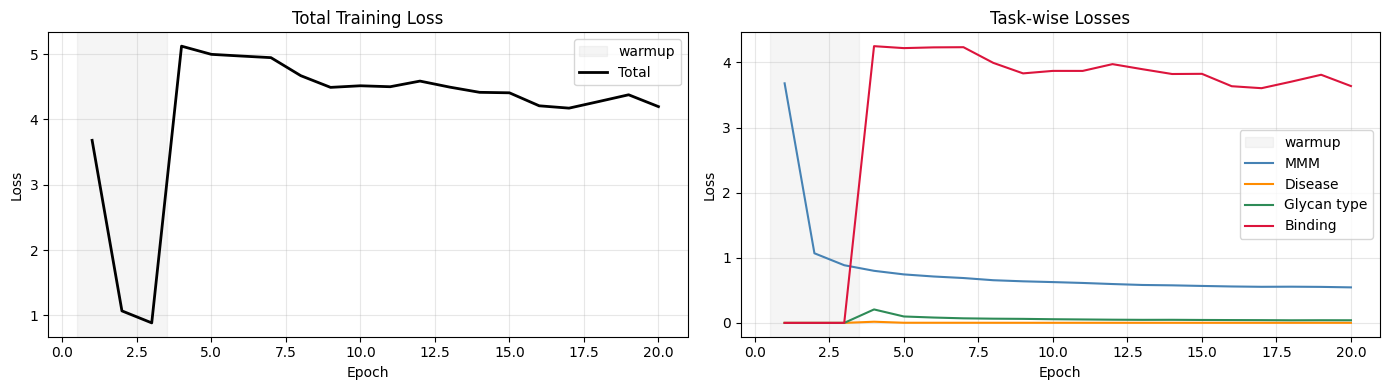

In [114]:
# Save model checkpoint
torch.save({
    'model_state_dict':  model.state_dict(),
    'vocab':             vocab,
    'top_tissues':       top_tissues,
    'top_species':       top_species,
    'top_diseases':      top_diseases,
    'glycan_types':      glycan_types,
    'history':           history,
}, 'data/glycan_embedding/glycanbert_checkpoint.pt')
print('Checkpoint saved.')

# Loss curves
hdf = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

warmup_end = hdf[hdf['phase'] == 'warmup']['epoch'].max()

for ax in axes:
    ax.axvspan(0.5, warmup_end + 0.5, alpha=0.08, color='gray', label='warmup')

axes[0].plot(hdf['epoch'], hdf['total'], lw=2, color='black', label='Total')
axes[0].set_title('Total Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3); axes[0].legend()

task_colors = {
    'mmm':        ('steelblue',   'MMM'),
    'disease':    ('darkorange',  'Disease'),
    'glycantype': ('seagreen',    'Glycan type'),
    'binding':    ('crimson',     'Binding'),
}
for task, (color, label) in task_colors.items():
    axes[1].plot(hdf['epoch'], hdf[task], lw=1.5, color=color, label=label)
axes[1].set_title('Task-wise Losses'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].grid(alpha=0.3); axes[1].legend()

plt.tight_layout()
plt.savefig('data/glycan_embedding/loss_curves.png', dpi=120, bbox_inches='tight')
plt.show()


## Skip training and load model

In [26]:
# Load trained GlycanBERT checkpoint
# Run this cell to restore the model for visualization without retraining.

CKPT_PATH = 'data/glycan_embedding/glycanbert_checkpoint.pt'
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)

# Restore vocabularies
vocab          = ckpt['vocab']
idx_to_token   = {v: k for k, v in vocab.items()}
top_tissues    = ckpt['top_tissues']
top_species    = ckpt['top_species']
top_diseases   = ckpt['top_diseases']
glycan_types   = ckpt['glycan_types']
disease_to_idx    = {d: i for i, d in enumerate(top_diseases)}
glycantype_to_idx = {t: i for i, t in enumerate(glycan_types)}

PAD_IDX  = vocab['[PAD]']
CLS_IDX  = vocab['[CLS]']
SEP_IDX  = vocab['[SEP]']
MASK_IDX = vocab['[MASK]']
UNK_IDX  = vocab['[UNK]']
VOCAB_SIZE = len(vocab)
GLYCAN_TOKEN_START = 5 + len(top_tissues) + len(top_species)  # special + tissue + species

# Rebuild model with the same architecture and load weights
model = GlycanBERT(
    vocab_size     = VOCAB_SIZE,
    d_model        = 256,
    nhead          = 8,
    num_layers     = 4,
    dim_feedforward= 512,
    dropout        = 0.1,
    max_len        = MAX_LEN,
    n_diseases     = len(top_diseases),
    n_glycantypes  = len(glycan_types),
    n_binding      = N_BINDING_COMPONENTS,
).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print(f'Checkpoint loaded from {CKPT_PATH}')
print(f'  vocab size    : {VOCAB_SIZE}')
print(f'  top_tissues   : {len(top_tissues)}')
print(f'  top_species   : {len(top_species)}')
print(f'  top_diseases  : {len(top_diseases)}')
print(f'  glycan_types  : {glycan_types}')
if 'history' in ckpt:
    print(f'  trained epochs: {len(ckpt["history"])}  (final loss: {ckpt["history"][-1]["total"]:.4f})')

Checkpoint loaded from data/glycan_embedding/glycanbert_checkpoint.pt
  vocab size    : 2324
  top_tissues   : 282
  top_species   : 268
  top_diseases  : 59
  glycan_types  : ['N', 'O', 'free', 'lipid', 'repeat']
  trained epochs: 20  (final loss: 4.1952)


## Embedding Extraction & Visualization

In [28]:
@torch.no_grad()
def extract_embeddings(seqs: List[str], meta_dict: Dict, batch_size: int = 256) -> np.ndarray:
    """Run forward pass with mask_prob=0 and return [CLS] embeddings."""
    model.eval()
    ds = GlycanDataset(
        sequences=seqs,
        metadata_dict=meta_dict,
        binding_pca_dict={},
        vocab=vocab,
        top_tissues=top_tissues,
        top_species=top_species,
        top_diseases=top_diseases,
        disease_to_idx=disease_to_idx,
        glycantype_to_idx=glycantype_to_idx,
        max_len=MAX_LEN,
        mask_prob=0.0,   # no masking during inference
    )
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    embs = []
    for batch in loader:
        cls_emb, *_ = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        embs.append(cls_emb.cpu().numpy())
    return np.concatenate(embs, axis=0)


# Extract for all df_glycan sequences
print('Extracting embeddings for df_glycan ...')
df_embs = extract_embeddings(df_glycan_seqs, metadata_dict)
print(f'  df_glycan embeddings : {df_embs.shape}')

# Extract for glycan_list targets
target_meta = {
    row['glycan']: {
        'tissue_sample':       row['tissue_sample'],
        'tissue_species':      row['tissue_species'],
        'disease_association': [],
        'glycan_type':         '',
    }
    for _, row in glycan_list.iterrows()
}
print('Extracting embeddings for glycan_list targets ...')
target_embs = extract_embeddings(glycan_list['glycan'].tolist(), target_meta)
print(f'  target embeddings    : {target_embs.shape}')

print('Target glycan embedding norms:')
for i, (seq, emb) in enumerate(zip(glycan_list['glycan'], target_embs)):
    print(f'  [{i}] norm={np.linalg.norm(emb):.3f}  {seq[:70]}...')


Extracting embeddings for df_glycan ...
  df_glycan embeddings : (50461, 256)
Extracting embeddings for glycan_list targets ...
  target embeddings    : (5, 256)
Target glycan embedding norms:
  [0] norm=42.696  Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b...
  [1] norm=48.547  Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b...
  [2] norm=44.981  Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1...
  [3] norm=43.173  Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b...
  [4] norm=36.969  Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(...


UMAP not found — using t-SNE  (install with: pip install umap-learn)
Projecting 30,712 embeddings ...
Done.


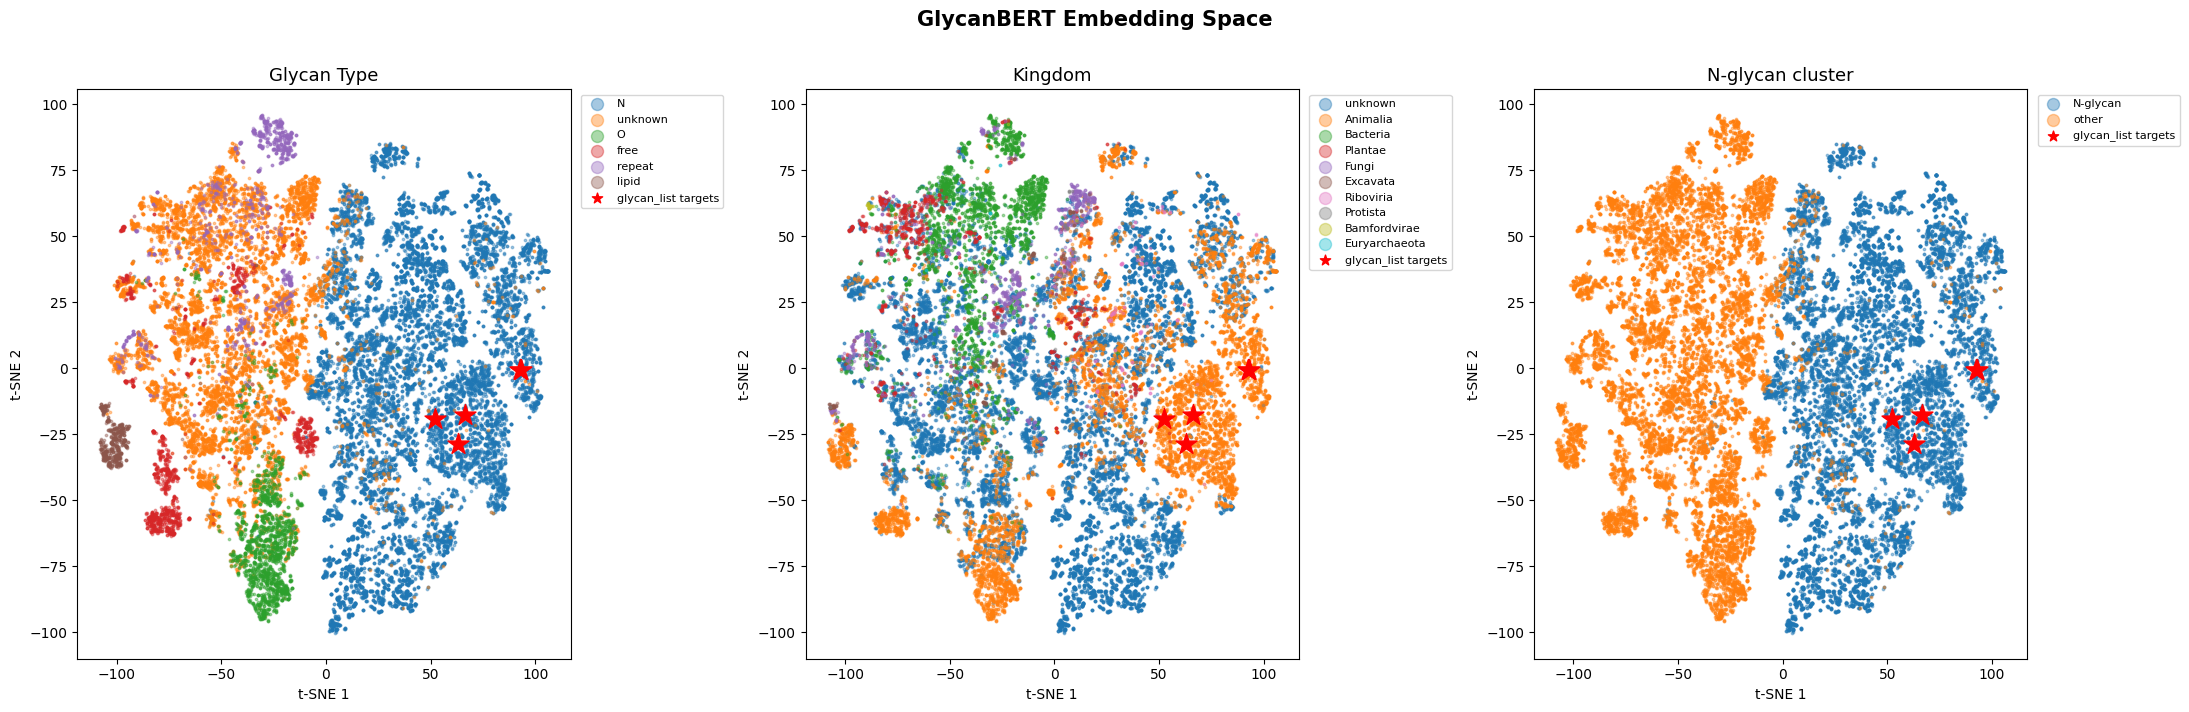

Saved to data/glycan_embedding/embedding_space.png


In [20]:
# ---------- t-SNE (or UMAP if installed) ----------
# To use UMAP: pip install umap-learn
try:
    import umap
    Reducer = lambda: umap.UMAP(n_components=2, random_state=SEED, n_neighbors=30, min_dist=0.1)
    label_x, label_y = 'UMAP-1', 'UMAP-2'
    print('Using UMAP')
except ImportError:
    Reducer = lambda: TSNE(n_components=2, random_state=SEED, perplexity=50, n_jobs=-1)
    label_x, label_y = 't-SNE 1', 't-SNE 2'
    print('UMAP not found — using t-SNE  (install with: pip install umap-learn)')

# Subsample for projection: all N-glycans + up to 15 000 random others
n_glycan_set   = set(n_glycan_seqs)
ng_indices     = [i for i, s in enumerate(df_glycan_seqs) if s in n_glycan_set]
other_indices  = [i for i in range(len(df_glycan_seqs)) if i not in set(ng_indices)]
rng            = np.random.default_rng(SEED)
rng.shuffle(other_indices)
selected_idx   = ng_indices + other_indices[:min(15_000, len(other_indices))]

sel_seqs = [df_glycan_seqs[i] for i in selected_idx]
sel_embs = df_embs[selected_idx]

print(f'Projecting {len(sel_embs):,} embeddings ...')
reducer  = Reducer()
emb_2d   = reducer.fit_transform(sel_embs)

# Project targets separately with UMAP transform (or append for t-SNE)
if hasattr(reducer, 'transform'):
    target_2d = reducer.transform(target_embs)
else:
    # For t-SNE: reproject all together
    combined  = np.vstack([sel_embs, target_embs])
    combined2d = TSNE(n_components=2, random_state=SEED, perplexity=50, n_jobs=-1).fit_transform(combined)
    emb_2d, target_2d = combined2d[:len(sel_embs)], combined2d[len(sel_embs):]

print('Done.')

# ---- Collect colour labels ----
df_meta_lookup = df_glycan.set_index('glycan')
glycan_types, kingdoms = [], []
for seq in sel_seqs:
    row = df_meta_lookup.loc[seq]
    gt  = row['glycan_type']
    glycan_types.append(gt if isinstance(gt, str) and gt else 'unknown')
    k   = row['Kingdom']
    kingdoms.append((k[0] if k[0] else 'unknown') if isinstance(k, list) and k else 'unknown')
    
is_n_glycan = ['N-glycan' if s in n_glycan_set else 'other' for s in sel_seqs]

# ---- Plot ----
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

def scatter_by_label(ax, emb, labels, title, target_xy=None):
    uniq = pd.Series(labels).value_counts().index.tolist()
    for i, lab in enumerate(uniq[:10]):
        m = np.array(labels) == lab
        ax.scatter(emb[m, 0], emb[m, 1], s=3, alpha=0.4, color=colors[i % len(colors)], label=lab)
    if target_xy is not None:
        ax.scatter(target_xy[:, 0], target_xy[:, 1], marker='*',s=250,
                   color='red', zorder=10, label='glycan_list targets')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel(label_x); ax.set_ylabel(label_y)
    leg = ax.legend(markerscale=5, fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
    leg.legend_handles[-1].set_sizes([60])
scatter_by_label(axes[0], emb_2d, glycan_types, 'Glycan Type',      target_2d)
scatter_by_label(axes[1], emb_2d, kingdoms,      'Kingdom',          target_2d)
scatter_by_label(axes[2], emb_2d, is_n_glycan,   'N-glycan cluster', target_2d)

plt.suptitle('GlycanBERT Embedding Space', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/glycan_embedding/embedding_space.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to data/glycan_embedding/embedding_space.png')

We can clearly see a good seperation between the different Glycan Types, Kingdom. For the kingdom and glycan type plots we have to "ignore" the unknown categories as they are unknown, and we clearly see a highly tight cluster of glycan type "O", as well as "repeat", "lipid" and "free", with very few points that are far from their clusters but still do not overlap with another cluster. The seperation is especially well seen for the N-glycan cluster as we have a linear boundary (which is the best possible type of boundary). And, it looks like the glycan sequences in ```glycan_list``` are most likely of type N. Let's compare our embeddings to the ones used in glycowork and from the Kingdom "animalia", which I'm assuming that means animal species, which agrees with their tissue_sample and tissue_species features saying that they came from humans.

## glycowork SweetNet Embeddings

Loading pretrained SweetNet ...


glycowork_sweetnet_species.pt:   0%|          | 0.00/3.29M [00:00<?, ?B/s]

Download completed.
SweetNet ready.
Embedding 30,712 sequences with SweetNet ...
  Valid: 30,712 / 30,712
  Targets valid: 5 / 5
Projecting 30,712 SweetNet embeddings ...
Done.


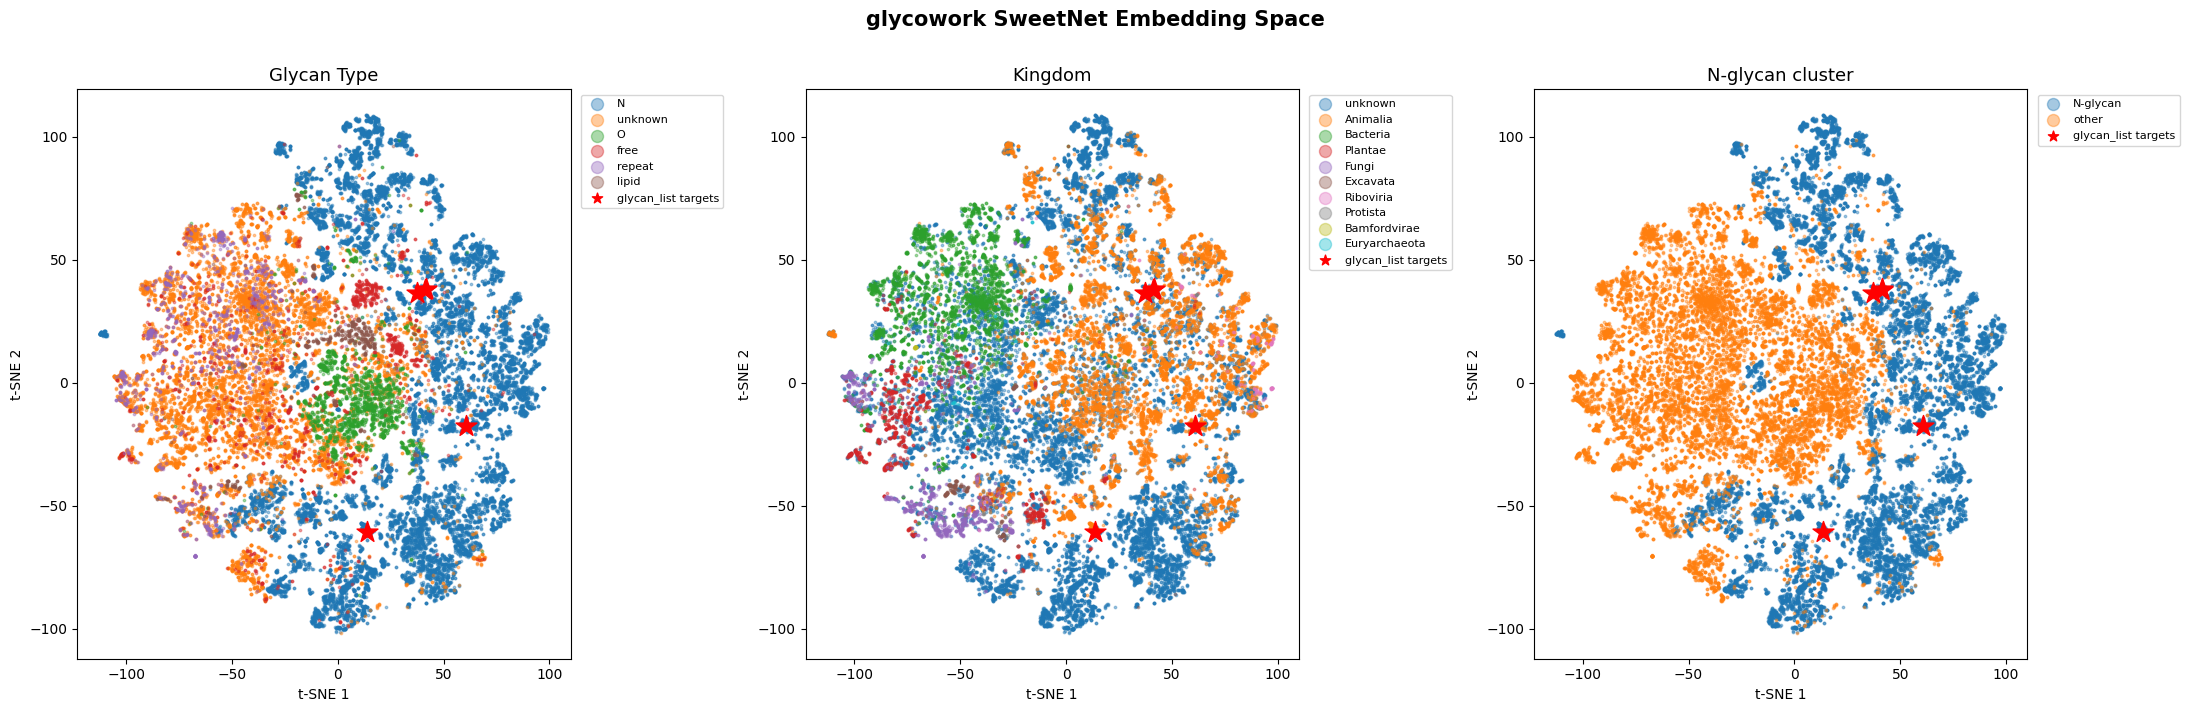

Saved to data/glycan_embedding/sweetnet_embedding_space.png


In [ ]:
# glycowork's pretrained SweetNet is a graph neural network trained on
# a glycan corpus with species supervision.
# glycans_to_emb(seqs, model, rep=True) returns learned graph-level representations.
# We project the same sequence subset used for GlycanBERT so the plots are comparable.

from glycowork.ml.models   import prep_model
from glycowork.ml.inference import glycans_to_emb

# ---- Load pretrained SweetNet (downloads checkpoint on first run) ----
print('Loading pretrained SweetNet ...')
sweetnet = prep_model('SweetNet', num_classes=1075, trained=True)
sweetnet.eval()
print('SweetNet ready.')

# ---- Helper: embed in chunks, silently skip sequences that fail ----
def sweetnet_embed(seqs, batch_size=256):
    """Returns (emb_array, valid_seqs) — invalid glycans are dropped."""
    embs, valid = [], []
    for i in range(0, len(seqs), batch_size):
        chunk = seqs[i : i + batch_size]
        try:
            df = glycans_to_emb(chunk, sweetnet, rep=True)
            embs.append(df.values)
            valid.extend(chunk)
        except Exception:
            # fall back: one-by-one to isolate failures
            for seq in chunk:
                try:
                    df = glycans_to_emb([seq], sweetnet, rep=True)
                    embs.append(df.values)
                    valid.append(seq)
                except Exception:
                    pass
    return (np.vstack(embs) if embs else np.empty((0, 0))), valid

# ---- Embed the same subset used for GlycanBERT plot ----
print(f'Embedding {len(sel_seqs):,} sequences with SweetNet ...')
sw_embs, sw_seqs = sweetnet_embed(sel_seqs)
print(f'  Valid: {len(sw_seqs):,} / {len(sel_seqs):,}')

# ---- Embed glycan_list targets ----
sw_target_embs, sw_target_seqs = sweetnet_embed(glycan_list['glycan'].tolist())
print(f'  Targets valid: {len(sw_target_seqs)} / {len(glycan_list)}')

# ---- 2-D projection (new fit — SweetNet space is independent of GlycanBERT) ----
print(f'Projecting {len(sw_embs):,} SweetNet embeddings ...')
sw_reducer = Reducer()      # same UMAP/t-SNE class chosen in the GlycanBERT section
sw_2d      = sw_reducer.fit_transform(sw_embs)

if hasattr(sw_reducer, 'transform') and len(sw_target_embs):
    sw_target_2d = sw_reducer.transform(sw_target_embs)
elif len(sw_target_embs):
    combined   = np.vstack([sw_embs, sw_target_embs])
    combined2d = TSNE(n_components=2, random_state=SEED, perplexity=50, n_jobs=-1).fit_transform(combined)
    sw_2d, sw_target_2d = combined2d[:len(sw_embs)], combined2d[len(sw_embs):]
else:
    sw_target_2d = None
print('Done.')

# ---- Colour labels (same categories as GlycanBERT plot) ----
sw_glycan_types, sw_kingdoms = [], []
for seq in sw_seqs:
    if seq in df_meta_lookup.index:
        row = df_meta_lookup.loc[seq]
        gt  = row['glycan_type']
        sw_glycan_types.append(gt if isinstance(gt, str) and gt else 'unknown')
        k   = row['Kingdom']
        sw_kingdoms.append((k[0] if k[0] else 'unknown') if isinstance(k, list) and k else 'unknown')
    else:
        sw_glycan_types.append('unknown')
        sw_kingdoms.append('unknown')

sw_is_n_glycan = ['N-glycan' if s in n_glycan_set else 'other' for s in sw_seqs]

# ---- Plot ----
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

scatter_by_label(axes[0], sw_2d, sw_glycan_types, 'Glycan Type',      sw_target_2d)
scatter_by_label(axes[1], sw_2d, sw_kingdoms,      'Kingdom',          sw_target_2d)
scatter_by_label(axes[2], sw_2d, sw_is_n_glycan,   'N-glycan cluster', sw_target_2d)

plt.suptitle('glycowork SweetNet Embedding Space', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('data/glycan_embedding/sweetnet_embedding_space.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to data/glycan_embedding/sweetnet_embedding_space.png')


First thing I notice is that for the N-glycan cluster, we don't have a linear boundary but rather like a crescent shape, and the glycan sequences from ```glycan_list``` lie almost on the boundary, making their embeddings not very meaningful and confident for their glycan type. Same thing can be said for Kingdom, where they lie at the boundary of animalia kingdom. There are some well defined clusters in the glycan type plot and kingdom plot, but there are a lot, or at least much more overlaps than in our model.

Overall, it looks like our model embeddings hold more meaningful embeddings than the model used by glycowork, which is expected since glycowork's SweetNet is a supervised-learning model that is pre-trained only on species classification, so their embeddings should be a lot less generalizable. In deep-learning literature, it has been shown that embeddings learned via self-supervision are much more rich, meaningful, and flexible than via fully supervised, because it learns intrinsic properties rather than guided and biased towards a certain tasks and also because unlabeled data are much much more larger in size than labeled data.

Now we will freeze the embeddings, directly use the classification heads that we used for training to infer classes for the glycan sequences in ```glycan_list``` and we're going to train classification heads for the other features in the training corpus and infer them for the sequences in ```glycan_list```

## Evaluation on downstream tasks

We're going to compare GlycanBERT and SweetNet embeddings through downstreal tasks like disease_assoc/glycan_type/kingdom/phylum/class/disease_direction/disease_sample classification and protein binding regression. We're going to train our model and evaluate on a K-fold cross validation split and take the average metrics over validation splits. When evaluating the validation metrics, we're going to freeze the model's embeddings and train a linear probe. 

In [38]:

# For each fold:
#   GlycanBERT : reinitialise + train from scratch (10 epochs),
#                evaluate existing heads (disease, glycan_type) on val,
#                train linear probes on frozen [CLS] for new tasks.
#   SweetNet   : pretrained (fixed), train linear probes on frozen
#                representations for all tasks.
#
# Tasks evaluated
#   - glycan_type       : 5-class CE  -> macro-F1
#   - disease_assoc     : multi-label -> macro-F1
#   - Kingdom / Phylum / Class (taxonomy) : multi-label -> macro-F1
#   - disease_direction : multi-label -> macro-F1
#   - disease_sample    : multi-label -> macro-F1

import copy, warnings
from sklearn.model_selection    import KFold
from sklearn.preprocessing      import MultiLabelBinarizer
from sklearn.linear_model       import LogisticRegression
from sklearn.multiclass         import OneVsRestClassifier
from sklearn.metrics            import f1_score
from sklearn.exceptions         import UndefinedMetricWarning

SEED    = 42
N_FOLDS = 3
N_CV_EPOCHS       = 5
N_CV_WARMUP       = 2
CV_BATCH_SIZE     = 256

# ── helper: build label arrays ──────────────────────────────────────────
def get_list_col(series):
    import ast
    result = []
    for v in series:
        if isinstance(v, list):
            result.append([x for x in v if x])
        elif isinstance(v, str) and v.startswith('['):
            result.append([x for x in ast.literal_eval(v) if x])
        else:
            result.append([])
    return result

# Precompute ALL label matrices once (aligned to df_glycan_seqs)
df_idx = df_glycan.set_index('glycan')

PROBE_COLS = [
    ('Kingdom',           'Kingdom'),
    ('Phylum',            'Phylum'),
    ('Class',             'Class'),
    ('disease_direction', 'Disease direction'),
    ('disease_sample',    'Disease sample'),
]

all_labels = {}   # name -> (mlb, Y [n, k])  aligned to df_glycan_seqs
for col, name in PROBE_COLS:
    rows = get_list_col(df_idx.loc[df_glycan_seqs, col])
    mlb  = MultiLabelBinarizer()
    Y    = mlb.fit_transform(rows)
    keep = Y.sum(axis=0) >= 2
    all_labels[name] = (mlb, Y[:, keep], keep)

# glycan_type as integer array (aligned to df_glycan_seqs)
gt_col   = df_idx.loc[df_glycan_seqs, 'glycan_type']
gt_int   = np.array([glycantype_to_idx.get(v, -1) for v in gt_col])

# disease multi-hot (aligned to df_glycan_seqs)
dis_rows = get_list_col(df_idx.loc[df_glycan_seqs, 'disease_association'])
dis_mlb  = MultiLabelBinarizer(classes=top_diseases)
Y_dis    = dis_mlb.fit_transform(dis_rows).astype(np.float32)

print('Label matrices ready.')
for name, (mlb, Y, _) in all_labels.items():
    print(f'  {name:<25s}: {Y.shape[1]:3d} classes, '
          f'{(Y.sum(1)>0).sum():,}/{len(Y):,} labelled')
print(f'  {"glycan_type":<25s}: {len(glycan_types):3d} classes, '
      f'{(gt_int>=0).sum():,}/{len(gt_int):,} labelled')
print(f'  {"disease_assoc":<25s}: {Y_dis.shape[1]:3d} classes, '
      f'{(Y_dis.sum(1)>0).sum():,}/{len(Y_dis):,} labelled')


Label matrices ready.
  Kingdom                  :  18 classes, 23,742/50,461 labelled
  Phylum                   :  61 classes, 23,741/50,461 labelled
  Class                    : 137 classes, 23,737/50,461 labelled
  Disease direction        :   2 classes, 463/50,461 labelled
  Disease sample           :  29 classes, 602/50,461 labelled
  glycan_type              :   5 classes, 27,171/50,461 labelled
  disease_assoc            :  59 classes, 602/50,461 labelled


In [39]:
# ── helper: fit probes + score on val ───────────────────────────────────
def probe_score(X_tr, X_val, Y_tr, Y_val, name=''):
    """OneVsRest logistic regression. Returns macro-F1 on val."""
    labelled = Y_tr.sum(axis=1) > 0
    if labelled.sum() < 10:
        return float('nan')
    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=500, C=1.0, solver='lbfgs'), n_jobs=-1
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        clf.fit(X_tr[labelled], Y_tr[labelled])
        Y_pred = clf.predict(X_val)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UndefinedMetricWarning)
        return f1_score(Y_val, Y_pred, average='macro', zero_division=0)


def eval_fold_embs(X_tr, X_val, tr_idx, val_idx,
                   model_dis_head=None, model_gt_head=None):
    """
    Given frozen embeddings for train/val:
    - Use model heads directly for disease + glycan_type (if provided).
    - Train probes for taxonomy + disease metadata.
    Returns dict of metric_name -> float.
    """
    metrics = {}

    # ---- glycan_type: model head or probe ----
    gt_tr  = gt_int[tr_idx];  gt_val = gt_int[val_idx]
    has_gt = gt_val >= 0
    if model_gt_head is not None and has_gt.any():
        with torch.no_grad():
            logits = model_gt_head(torch.tensor(X_val, dtype=torch.float32, device=device)).cpu().numpy()
        preds = logits.argmax(axis=1)[has_gt]
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', UndefinedMetricWarning)
            metrics['glycan_type'] = f1_score(gt_val[has_gt], preds, average='macro', zero_division=0)
    else:
        # probe fallback
        has_tr = gt_tr >= 0
        if has_tr.sum() >= 10 and has_gt.sum() >= 1:
            from sklearn.linear_model import LogisticRegression as LR
            clf = LR(max_iter=500, C=1.0, solver='lbfgs', multi_class='multinomial')
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                clf.fit(X_tr[has_tr], gt_tr[has_tr])
                preds = clf.predict(X_val[has_gt])
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', UndefinedMetricWarning)
                metrics['glycan_type'] = f1_score(gt_val[has_gt], preds, average='macro', zero_division=0)
        else:
            metrics['glycan_type'] = float('nan')

    # ---- disease_assoc: model head or probe ----
    Y_dis_tr = Y_dis[tr_idx];  Y_dis_val = Y_dis[val_idx]
    has_dis_val = Y_dis_val.sum(axis=1) > 0
    if model_dis_head is not None and has_dis_val.any():
        with torch.no_grad():
            logits = model_dis_head(torch.tensor(X_val, dtype=torch.float32, device=device)).cpu().numpy()
        preds = (logits > 0).astype(int)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', UndefinedMetricWarning)
            metrics['disease_assoc'] = f1_score(
                Y_dis_val[has_dis_val], preds[has_dis_val], average='macro', zero_division=0)
    else:
        metrics['disease_assoc'] = probe_score(X_tr, X_val, Y_dis_tr, Y_dis_val)

    # ---- linear probes for new tasks ----
    for name, (mlb, Y_all, _) in all_labels.items():
        Y_tr_p = Y_all[tr_idx];  Y_val_p = Y_all[val_idx]
        has_val = Y_val_p.sum(axis=1) > 0
        if not has_val.any():
            metrics[name] = float('nan')
        else:
            metrics[name] = probe_score(X_tr, X_val, Y_tr_p, Y_val_p, name)

    return metrics


In [40]:
# ── GlycanBERT 5-fold CV ────────────────────────────────────────────────
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
bert_fold_metrics = []

# Use only df_glycan_seqs for CV (binding_only_seqs have no labels)
n_train = len(df_glycan_seqs)
indices  = np.arange(n_train)

for fold, (tr_idx, val_idx) in enumerate(kf.split(indices)):
    print(f'\n── Fold {fold+1}/{N_FOLDS}  '
          f'(train={len(tr_idx):,}  val={len(val_idx):,}) ──')

    tr_seqs  = [df_glycan_seqs[i] for i in tr_idx]
    val_seqs = [df_glycan_seqs[i] for i in val_idx]

    # ---- Dataset & loader ----
    fold_ds = GlycanDataset(
        sequences=tr_seqs + binding_only_seqs,
        metadata_dict=metadata_dict, binding_pca_dict=binding_pca_dict,
        vocab=vocab, top_tissues=top_tissues, top_species=top_species,
        top_diseases=top_diseases, disease_to_idx=disease_to_idx,
        glycantype_to_idx=glycantype_to_idx,
        max_len=MAX_LEN, mask_prob=MASK_PROB,
    )
    fold_loader = DataLoader(fold_ds, batch_size=CV_BATCH_SIZE,
                             shuffle=True, num_workers=0, pin_memory=True)

    # ---- Fresh model + optimiser ----
    fold_model = GlycanBERT(
        vocab_size=VOCAB_SIZE, d_model=256, nhead=8, num_layers=4,
        dim_feedforward=512, dropout=0.1, max_len=MAX_LEN,
        n_diseases=len(top_diseases), n_glycantypes=len(glycan_types),
        n_binding=N_BINDING_COMPONENTS,
    ).to(device)

    fold_opt  = torch.optim.AdamW(fold_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    fold_sched = torch.optim.lr_scheduler.OneCycleLR(
        fold_opt, max_lr=LR, total_steps=N_CV_EPOCHS * len(fold_loader),
        pct_start=0.1, anneal_strategy='cos',
    )

    # ---- Train ----
    for epoch in range(1, N_CV_EPOCHS + 1):
        supervised = epoch > N_CV_WARMUP
        losses = train_epoch(fold_model, fold_loader, fold_opt, fold_sched,
                             supervised=supervised)
        print(f'  ep {epoch:2d}  total={losses["total"]:.3f}  '
              f'mmm={losses["mmm"]:.3f}  dis={losses["disease"]:.3f}  '
              f'gt={losses["glycantype"]:.3f}  bnd={losses["binding"]:.3f}')

    # ---- Freeze + extract embeddings ----
    fold_model.eval()
    for p in fold_model.parameters(): p.requires_grad_(False)

    X_tr_emb  = extract_embeddings(tr_seqs,  metadata_dict, batch_size=256)
    X_val_emb = extract_embeddings(val_seqs, metadata_dict, batch_size=256)

    # ---- Evaluate ----
    fold_metrics = eval_fold_embs(
        X_tr_emb, X_val_emb, tr_idx, val_idx,
        model_dis_head=fold_model.disease_head,
        model_gt_head=fold_model.glycantype_head,
    )
    bert_fold_metrics.append(fold_metrics)

    # swap extract_embeddings model reference back so it uses the global model
    for metric, val in fold_metrics.items():
        print(f'    {metric:<25s}: {val:.3f}' if not np.isnan(val) else f'    {metric:<25s}: n/a')

    del fold_model, fold_opt, fold_sched
    torch.cuda.empty_cache()

print('\nGlycanBERT CV done.')



── Fold 1/3  (train=33,640  val=16,821) ──
  ep  1  total=4.804  mmm=4.804  dis=0.000  gt=0.000  bnd=0.000
  ep  2  total=1.692  mmm=1.692  dis=0.000  gt=0.000  bnd=0.000
  ep  3  total=5.285  mmm=1.226  dis=0.114  gt=0.637  bnd=3.811
  ep  4  total=4.947  mmm=1.121  dis=0.003  gt=0.258  bnd=3.747
  ep  5  total=5.047  mmm=1.090  dis=0.003  gt=0.211  bnd=3.891
    glycan_type              : 0.058
    disease_assoc            : 0.048
    Kingdom                  : 0.322
    Phylum                   : 0.247
    Class                    : 0.232
    Disease direction        : 0.014
    Disease sample           : 0.011

── Fold 2/3  (train=33,641  val=16,820) ──
  ep  1  total=4.795  mmm=4.795  dis=0.000  gt=0.000  bnd=0.000
  ep  2  total=1.722  mmm=1.722  dis=0.000  gt=0.000  bnd=0.000
  ep  3  total=5.395  mmm=1.242  dis=0.108  gt=0.629  bnd=3.910
  ep  4  total=5.064  mmm=1.132  dis=0.003  gt=0.283  bnd=3.846


KeyboardInterrupt: 

In [ ]:
# ── SweetNet 5-fold CV (pretrained, no re training) ──────────────────────
print('Loading SweetNet for CV ...')
from glycowork.ml.models   import prep_model
from glycowork.ml.inference import glycans_to_emb as gw_emb

sw_model = prep_model('SweetNet', num_classes=1075, trained=True)
sw_model.eval()

def sw_extract(seqs, batch_size=256):
    """Return (emb_array, valid_mask) for a list of glycan sequences."""
    embs, valid = [], np.zeros(len(seqs), dtype=bool)
    for i in range(0, len(seqs), batch_size):
        chunk = seqs[i:i+batch_size]
        try:
            df = gw_emb(chunk, sw_model, rep=True)
            embs.append(df.values)
            valid[i:i+len(chunk)] = True
        except Exception:
            for j, seq in enumerate(chunk):
                try:
                    df = gw_emb([seq], sw_model, rep=True)
                    embs.append(df.values)
                    valid[i+j] = True
                except Exception:
                    pass
    arr = np.vstack(embs) if embs else np.empty((0, 0))
    return arr, valid

sw_fold_metrics = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(indices)):
    print(f'\n── SweetNet Fold {fold+1}/{N_FOLDS} ──')
    tr_seqs  = [df_glycan_seqs[i] for i in tr_idx]
    val_seqs = [df_glycan_seqs[i] for i in val_idx]

    X_tr_sw,  tr_ok  = sw_extract(tr_seqs)
    X_val_sw, val_ok = sw_extract(val_seqs)

    # Map back to original indices (drop sequences SweetNet can't parse)
    tr_idx_ok  = tr_idx[tr_ok]
    val_idx_ok = val_idx[val_ok]

    fold_metrics = eval_fold_embs(
        X_tr_sw, X_val_sw,
        tr_idx_ok, val_idx_ok,
        model_dis_head=None,   # no model heads — probes only
        model_gt_head=None,
    )
    sw_fold_metrics.append(fold_metrics)
    for metric, val in fold_metrics.items():
        print(f'    {metric:<25s}: {val:.3f}' if not np.isnan(val) else f'    {metric:<25s}: n/a')

print('\nSweetNet CV done.')


In [ ]:
# ── Results table ────────────────────────────────────────────────────────
all_metrics = list(bert_fold_metrics[0].keys())
rows = []
for metric in all_metrics:
    bert_vals = [m[metric] for m in bert_fold_metrics if not np.isnan(m[metric])]
    sw_vals   = [m[metric] for m in sw_fold_metrics   if not np.isnan(m[metric])]
    rows.append({
        'Task':                    metric,
        'GlycanBERT mean F1':      np.mean(bert_vals) if bert_vals else float('nan'),
        'GlycanBERT std':          np.std(bert_vals)  if bert_vals else float('nan'),
        'SweetNet mean F1':        np.mean(sw_vals)   if sw_vals   else float('nan'),
        'SweetNet std':            np.std(sw_vals)    if sw_vals   else float('nan'),
    })

cv_results = pd.DataFrame(rows).set_index('Task')
cv_results = cv_results.round(3)
print(f'\n-------- {N_FOLDS}-Fold CV Results (macro-F1) --------')
display(cv_results)

# ── Bar chart ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

x   = np.arange(len(all_metrics))
w   = 0.35
fig, ax = plt.subplots(figsize=(13, 5))

bert_means = cv_results['GlycanBERT mean F1'].values
bert_stds  = cv_results['GlycanBERT std'].values
sw_means   = cv_results['SweetNet mean F1'].values
sw_stds    = cv_results['SweetNet std'].values

ax.bar(x - w/2, bert_means, w, yerr=bert_stds,  label='GlycanBERT', capsize=4, color='steelblue')
ax.bar(x + w/2, sw_means,   w, yerr=sw_stds,    label='SweetNet',   capsize=4, color='darkorange')

ax.set_xticks(x); ax.set_xticklabels(all_metrics, rotation=25, ha='right')
ax.set_ylabel('Macro F1'); ax.set_ylim(0, 1)
ax.set_title(f'{N_FOLDS}-Fold CV: GlycanBERT vs SweetNet (frozen embeddings, linear probes)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('data/glycan_embedding/cv_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## Inference on glycan_list with Frozen GlycanBERT and linear probes


Now we're going to use frozen GlycanBERT embeddings that were trained on the whole dataset, and add a linear probe for each classification/regression task, train the linear probe and use it to do some inferences on the glycan sequences in ```glycan_list``` to get more information about them.

In [29]:
# Extract frozen [CLS] embeddings
# We extract once and reuse for both the existing heads and the new probes.

model.eval()
for p in model.parameters():
    p.requires_grad_(False)

print('Extracting train embeddings (df_glycan) ...')
train_embs = extract_embeddings(df_glycan_seqs, metadata_dict)
print(f'  shape: {train_embs.shape}')

print('Extracting glycan_list target embeddings ...')
target_embs = extract_embeddings(glycan_list['glycan'].tolist(), target_meta)
print(f'  shape: {target_embs.shape}')


Extracting train embeddings (df_glycan) ...
  shape: (50461, 256)
Extracting glycan_list target embeddings ...
  shape: (5, 256)


In [33]:
# ── Step 2: Infer with existing trained heads ─────────────────────────────
target_tensor = torch.tensor(target_embs, dtype=torch.float32, device=device)

with torch.no_grad():
    dis_logits = model.disease_head(target_tensor).cpu()
    gt_logits  = model.glycantype_head(target_tensor).cpu()
    bnd_pred   = model.binding_head(target_tensor).cpu()

# Disease: sigmoid + threshold 0.3
dis_probs  = torch.sigmoid(dis_logits).numpy()
dis_preds  = []
for row in dis_probs:
    labels = [top_diseases[i] for i, p in enumerate(row) if p > 0.3]
    dis_preds.append(labels if labels else ['none predicted'])

# Glycan type: argmax
gt_preds = [glycan_types[i] for i in gt_logits.argmax(dim=1).numpy()]

# Binding: reconstruct from PCA (inverse_transform) for interpretability
bnd_array  = bnd_pred.numpy()
bnd_recon  = binding_scaler.inverse_transform(binding_pca.inverse_transform(bnd_array))
bnd_df     = pd.DataFrame(bnd_recon, columns=glycan_binding['protein'].values, index=glycan_list['glycan'])
# Top-3 predicted binding partners per target glycan
top_binders = {}
for seq in glycan_list['glycan']:
    row = bnd_df.loc[seq]
    top_binders[seq] = row.nlargest(3).index.tolist()

print('----- Existing head predictions for glycan_list -----')
for i, seq in enumerate(glycan_list['glycan']):
    print(f'\n[{i}] {seq[:80]}')
    print(f'  glycan_type      : {gt_preds[i]}')
    print(f'  disease_assoc    : {dis_preds[i]}')
    print(f'  top-3 binders    : {top_binders[seq]}')


----- Existing head predictions for glycan_list -----

[0] Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a
  glycan_type      : N
  disease_assoc    : ['none predicted']
  top-3 binders    : ['BGL', 'BGL', 'BGL']

[1] Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc
  glycan_type      : N
  disease_assoc    : ['none predicted']
  top-3 binders    : ['PhoSpL', 'PHA-L(A)', 'AAL']

[2] Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1
  glycan_type      : N
  disease_assoc    : ['none predicted']
  top-3 binders    : ['SNA', 'RCA-1', 'A/Albany/42/1975 (H3N2)']

[3] Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc
  glycan_type      : N
  disease_assoc    : ['none predicted']
  top-3 binders    : ['SNA', 'A/Albany/42/1975 (H3N2)', 'A/BCM/1/1980(H3N2)']

[4] Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a
  glycan_type      : N
  di

In [34]:
# Build label arrays for new linear probes 
from sklearn.preprocessing import MultiLabelBinarizer

def get_list_col(df, col):
    """Return column as a list-of-lists, handling both list and string repr."""
    import ast
    result = []
    for v in df[col]:
        if isinstance(v, list):
            result.append([x for x in v if x])
        elif isinstance(v, str) and v.startswith('['):
            result.append([x for x in ast.literal_eval(v) if x])
        else:
            result.append([])
    return result

# Align to df_glycan_seqs order
df_indexed = df_glycan.set_index('glycan')

probe_targets = {}  # name -> (MLB, Y_train  [n_train, n_classes])

for col, name in [
    ('Kingdom',          'Kingdom'),
    ('Phylum',           'Phylum'),
    ('Class',            'Class (taxonomy)'),
    ('disease_direction','Disease direction'),
    ('disease_sample',   'Disease sample tissue'),
]:
    rows = get_list_col(df_indexed.loc[df_glycan_seqs], col)
    mlb  = MultiLabelBinarizer()
    Y    = mlb.fit_transform(rows)
    # Only keep if at least 2 positive examples per class
    keep      = Y.sum(axis=0) >= 2
    Y         = Y[:, keep]
    mlb.classes_ = mlb.classes_[keep]
    probe_targets[name] = (mlb, Y)
    print(f'{name:<25s}: {len(mlb.classes_):3d} classes, '
          f'{(Y.sum(axis=1) > 0).sum():,} / {len(Y):,} sequences labelled')


Kingdom                  :  18 classes, 23,742 / 50,461 sequences labelled
Phylum                   :  61 classes, 23,741 / 50,461 sequences labelled
Class (taxonomy)         : 137 classes, 23,737 / 50,461 sequences labelled
Disease direction        :   2 classes, 463 / 50,461 sequences labelled
Disease sample tissue    :  29 classes, 602 / 50,461 sequences labelled


In [35]:
# Train linear probes on frozen embeddings 
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass   import OneVsRestClassifier
from sklearn.metrics      import f1_score
import warnings

probe_results = {}   # name -> list of predicted label-lists for glycan_list

for name, (mlb, Y_train) in probe_targets.items():
    # Skip rows with no labels (no supervision signal)
    labelled     = Y_train.sum(axis=1) > 0
    X_tr, Y_tr   = train_embs[labelled], Y_train[labelled]

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs'),
        n_jobs=-1,
    )
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        clf.fit(X_tr, Y_tr)

    # Quick train F1 as a sanity check
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        train_f1 = f1_score(Y_tr, clf.predict(X_tr), average='macro', zero_division=0)

    # Predict for glycan_list
    Y_pred   = clf.predict(target_embs)                  # [5, n_classes]
    Y_proba  = clf.predict_proba(target_embs)            # [5, n_classes]

    preds = []
    for row_bin, row_prob in zip(Y_pred, Y_proba):
        labels = mlb.classes_[row_bin.astype(bool)].tolist()
        if not labels:
            # fallback: top-1 by probability
            labels = [mlb.classes_[row_prob.argmax()]]
        preds.append(labels)

    probe_results[name] = preds
    print(f'{name:<25s}: train macro-F1={train_f1:.3f}')

print('\nDone.')


Kingdom                  : train macro-F1=0.755
Phylum                   : train macro-F1=0.712
Class (taxonomy)         : train macro-F1=0.736
Disease direction        : train macro-F1=0.925
Disease sample tissue    : train macro-F1=0.995

Done.


In [37]:
# ── Step 5: Summary table + CSV export ───────────────────────────────────
rows = []
for i, seq in enumerate(glycan_list['glycan']):
    row = {
        'glycan':        seq,
        'glycan_type':   gt_preds[i],
        'disease_assoc': ', '.join(dis_preds[i]),
        'top3_binders':  ', '.join(top_binders[seq]),
    }
    for name, preds in probe_results.items():
        row[name] = ', '.join(preds[i])
    rows.append(row)

predicted_df = pd.DataFrame(rows).set_index('glycan')

# Merge with original glycan_list features
glycan_list_indexed = glycan_list.set_index('glycan')
output_df = glycan_list_indexed.join(predicted_df, how='left')

# Stringify list columns for clean CSV output
for col in output_df.columns:
    if output_df[col].apply(lambda x: isinstance(x, list)).any():
        output_df[col] = output_df[col].apply(
            lambda x: ', '.join(str(v) for v in x) if isinstance(x, list) else x
        )

OUT_PATH = 'data/glycan_embedding/glycan_list_predictions.csv'
output_df.to_csv(OUT_PATH)
print(f'Saved to {OUT_PATH}')
print(f'Shape: {output_df.shape}  ({len(output_df)} glycans, {len(output_df.columns)} columns)')
print()

pd.set_option('display.max_colwidth', 40)
pd.set_option('display.width', 200)
print('----- glycan_list with predictions -----')
display(output_df)


Saved to data/glycan_embedding/glycan_list_predictions.csv
Shape: (5, 11)  (5 glycans, 11 columns)

----- glycan_list with predictions -----


,Composition,tissue_species,tissue_sample,glycan_type,disease_assoc,top3_binders,Kingdom,Phylum,Class (taxonomy),Disease direction,Disease sample tissue
glycan,,,,,,,,,,,
Fuc(a1-?)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,"{'dHex': 2, 'HexNAc': 4, 'Hex': 3}",Homo_sapiens,blood,N,none predicted,"BGL, BGL, BGL",Animalia,Chordata,Mammalia,"down, up","serum, tumor"
Neu5Ac(a2-?)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)[Fuc(a1-6)]GlcNAc,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4,...",Homo_sapiens,blood,N,none predicted,"PhoSpL, PHA-L(A), AAL",Animalia,Chordata,Mammalia,up,serum
Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc,"{'Neu5Ac': 1, 'Hex': 5, 'HexNAc': 4}",Homo_sapiens,blood,N,none predicted,"SNA, RCA-1, A/Albany/42/1975 (H3N2)",Animalia,Chordata,Mammalia,up,prostate_cancer_biopsy
Neu5Ac(a2-6)Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc,"{'Neu5Ac': 1, 'Hex': 4, 'HexNAc': 4}",Homo_sapiens,blood,N,none predicted,"SNA, A/Albany/42/1975 (H3N2), A/BCM/...",Animalia,Chordata,Mammalia,"down, up",sputum
Fuc(a1-2)[GalNAc(a1-3)]Gal(b1-4)GlcNAc(b1-2)Man(a1-6)[Gal(b1-4)GlcNAc(b1-2)Man(a1-3)]Man(b1-4)GlcNAc(b1-4)GlcNAc,"{'dHex': 1, 'HexNAc': 5, 'Hex': 5}",Homo_sapiens,blood,N,none predicted,"AAL, DrGRIFIN, CvGal2",Animalia,Chordata,Mammalia,down,"tumor_EGFR_pos, tumor_late_stage"
